In [5]:
"""
Similarity Score Analysis Notebook
Analyzes similarity scores for Hit@1,2,3 and compares embedding-based similarity with LLM-as-a-judge scores.
Uses precomputed all-MiniLM-L6-v2 embeddings.
"""

import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
from sentence_transformers import SentenceTransformer
import os
import sys

# Get the notebook's directory and add parent directory to path for config import
# Notebook is in: LLM/analysis/
# Config is in: LLM/core/config.py
# Try to find the LLM directory by looking for the analysis folder or core/config.py
current_dir = os.getcwd()
llm_dir = None

# Strategy 1: Check if we're already in the LLM directory
if os.path.exists(os.path.join(current_dir, 'core', 'config.py')):
    llm_dir = current_dir
# Strategy 2: Check if we're in the analysis subdirectory
elif os.path.basename(current_dir) == 'analysis' and os.path.exists(os.path.join(os.path.dirname(current_dir), 'core', 'config.py')):
    llm_dir = os.path.dirname(current_dir)
# Strategy 3: Walk up the directory tree to find LLM directory
else:
    search_dir = os.path.abspath(current_dir)
    while search_dir:
        if os.path.exists(os.path.join(search_dir, 'core', 'config.py')):
            llm_dir = search_dir
            break
        parent = os.path.dirname(search_dir)
        if parent == search_dir:  # Reached filesystem root
            break
        search_dir = parent

if llm_dir:
    sys.path.insert(0, llm_dir)
    notebook_dir = llm_dir  # Use for env path resolution
else:
    # Last resort: assume we're in analysis folder relative to LLM
    notebook_dir = os.path.join(os.path.dirname(current_dir) if os.path.basename(current_dir) == 'analysis' else current_dir)
    if os.path.basename(notebook_dir) != 'LLM':
        # Try to construct path
        potential_llm = os.path.dirname(notebook_dir) if os.path.basename(notebook_dir) == 'analysis' else notebook_dir
        if os.path.exists(os.path.join(potential_llm, 'core', 'config.py')):
            llm_dir = potential_llm
            sys.path.insert(0, llm_dir)
            notebook_dir = llm_dir

# Load environment variables
from dotenv import load_dotenv
# Try multiple possible .env locations
env_paths = [
    os.path.join(os.path.dirname(notebook_dir), '.env'),  # LLM/.env
    os.path.join(os.path.dirname(os.path.dirname(notebook_dir)), '.env'),  # stage_2_Modular_solution/.env
    os.path.join(notebook_dir, '.env'),  # analysis/.env
]
for env_path in env_paths:
    if os.path.exists(env_path):
        load_dotenv(env_path)
        break

# Import from core.config (config is now in core/ subdirectory)
from core.config import RESULTS_DIR, EMBEDDINGS_PATH, EMBEDDING_MODEL, SCAR_PATH, SIMILARITY_THRESHOLD

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Imports completed successfully!")
print(f"Embedding model: {EMBEDDING_MODEL}")
print(f"Results directory: {RESULTS_DIR}")


Imports completed successfully!
Embedding model: all-MiniLM-L6-v2
Results directory: d:\My_working_area\Masters\Thesis\code\Toward-Usable-Scientific-Analogies\Toward-Usable-Scientific-Analogies\stage_2_Modular_solution\LLM\results


In [6]:
# Load aggregated results
targetonly_path = os.path.join(RESULTS_DIR, 'all_results_targetonly.csv')
withsub_path = os.path.join(RESULTS_DIR, 'all_results_withsub.csv')

dfs = []
if os.path.exists(targetonly_path):
    df_to = pd.read_csv(targetonly_path)
    dfs.append(df_to)
    print(f"Loaded: {targetonly_path} ({len(df_to)} records)")

if os.path.exists(withsub_path):
    df_ws = pd.read_csv(withsub_path)
    dfs.append(df_ws)
    print(f"Loaded: {withsub_path} ({len(df_ws)} records)")

if not dfs:
    raise FileNotFoundError("No aggregated results found! Please run aggregate_results.py first.")

df = pd.concat(dfs, ignore_index=True)
print(f"\nTotal records: {len(df)}")
print(f"Models: {df['model'].nunique()}")
print(f"Modes: {df['mode'].unique().tolist()}")

# Load precomputed gold embeddings (read-only, for reference)
if os.path.exists(EMBEDDINGS_PATH):
    with open(EMBEDDINGS_PATH, 'rb') as f:
        gold_embeddings_data = pickle.load(f)
    print(f"\nLoaded {len(gold_embeddings_data['gold_sources'])} precomputed gold source embeddings")
else:
    print(f"\nWarning: Gold embeddings file not found at {EMBEDDINGS_PATH}")
    gold_embeddings_data = None

# Initialize SentenceTransformer embedder for target-to-analogy similarity computation
print(f"\nInitializing SentenceTransformer embedder: {EMBEDDING_MODEL}")
embedder = SentenceTransformer(EMBEDDING_MODEL)
print("Embedder ready!")

# Create output directory for visualizations
output_dir = os.path.join(RESULTS_DIR, 'similarity_analysis')
os.makedirs(output_dir, exist_ok=True)
print(f"\nOutput directory: {output_dir}")


Loaded: d:\My_working_area\Masters\Thesis\code\Toward-Usable-Scientific-Analogies\Toward-Usable-Scientific-Analogies\stage_2_Modular_solution\LLM\results\all_results_targetonly.csv (3852 records)
Loaded: d:\My_working_area\Masters\Thesis\code\Toward-Usable-Scientific-Analogies\Toward-Usable-Scientific-Analogies\stage_2_Modular_solution\LLM\results\all_results_withsub.csv (3852 records)

Total records: 7704
Models: 12
Modes: ['targetonly', 'withsub']

Loaded 333 precomputed gold source embeddings

Initializing SentenceTransformer embedder: all-MiniLM-L6-v2
Embedder ready!

Output directory: d:\My_working_area\Masters\Thesis\code\Toward-Usable-Scientific-Analogies\Toward-Usable-Scientific-Analogies\stage_2_Modular_solution\LLM\results\similarity_analysis


## SCAR Dataset Analysis: Target-Source Similarity Distribution

This section analyzes the SCAR dataset itself to understand what similarity scores look like for **correct analogies** (gold target-source pairs). This helps determine an appropriate threshold for semantic matching.


In [7]:
# Load SCAR dataset and compute target-source similarity
# SCAR_PATH is already imported from core.config in cell 0

print("=" * 70)
print("SCAR Dataset: Target-Source Similarity Analysis")
print("=" * 70)

# Load SCAR dataset
print(f"\nLoading SCAR dataset from: {SCAR_PATH}")
scar_df = pd.read_csv(SCAR_PATH)
print(f"Loaded {len(scar_df)} target-source pairs")

# Check column names
print(f"\nDataset columns: {scar_df.columns.tolist()}")

# Compute similarity for each target-source pair
print(f"\nComputing target-source similarity using {EMBEDDING_MODEL}...")
print("This may take a few minutes...")

scar_similarities = []

for idx, row in scar_df.iterrows():
    target = str(row.get('system_a', '')).strip()
    source = str(row.get('system_b', '')).strip()
    
    if not target or not source or target == 'nan' or source == 'nan':
        continue
    
    try:
        # Compute similarity using all-MiniLM-L6-v2
        target_emb = embedder.encode([target.lower()])[0]
        source_emb = embedder.encode([source.lower()])[0]
        
        similarity = np.dot(target_emb, source_emb) / (
            np.linalg.norm(target_emb) * np.linalg.norm(source_emb) + 1e-8
        )
        
        scar_similarities.append({
            'target': target,
            'source': source,
            'similarity': float(similarity)
        })
    except Exception as e:
        print(f"Error processing row {idx}: {e}")
        continue
    
    if (idx + 1) % 100 == 0:
        print(f"  Processed {idx + 1}/{len(scar_df)} pairs...")

scar_sim_df = pd.DataFrame(scar_similarities)
print(f"\nComputed {len(scar_sim_df)} target-source similarities")

# Statistics
print("\n" + "=" * 70)
print("SCAR Dataset Similarity Statistics")
print("=" * 70)
print(f"Total pairs: {len(scar_sim_df)}")
print(f"Mean similarity: {scar_sim_df['similarity'].mean():.4f}")
print(f"Median similarity: {scar_sim_df['similarity'].median():.4f}")
print(f"Std deviation: {scar_sim_df['similarity'].std():.4f}")
print(f"Min similarity: {scar_sim_df['similarity'].min():.4f}")
print(f"Max similarity: {scar_sim_df['similarity'].max():.4f}")
print(f"\nPercentiles:")
for p in [5, 10, 25, 50, 75, 90, 95]:
    val = scar_sim_df['similarity'].quantile(p/100)
    print(f"  {p}th percentile: {val:.4f}")


SCAR Dataset: Target-Source Similarity Analysis

Loading SCAR dataset from: d:\My_working_area\Masters\Thesis\code\Toward-Usable-Scientific-Analogies\Toward-Usable-Scientific-Analogies\stage_2_Modular_solution\LLM\..\..\data\SCAR_cleaned_manually.csv
Loaded 400 target-source pairs

Dataset columns: ['id', 'system_a', 'system_b', 'system_a_domain', 'system_b_domain', 'system_a_background', 'system_b_background', 'mappings_parsed', 'mapping_count', 'explanation_parsed', 'explanation_count', 'system_a_bg_wc', 'system_b_bg_wc']

Computing target-source similarity using all-MiniLM-L6-v2...
This may take a few minutes...


  Processed 100/400 pairs...
  Processed 200/400 pairs...
  Processed 300/400 pairs...
  Processed 400/400 pairs...

Computed 400 target-source similarities

SCAR Dataset Similarity Statistics
Total pairs: 400
Mean similarity: 0.3109
Median similarity: 0.2832
Std deviation: 0.1729
Min similarity: -0.0151
Max similarity: 1.0000

Percentiles:
  5th percentile: 0.0907
  10th percentile: 0.1249
  25th percentile: 0.1943
  50th percentile: 0.2832
  75th percentile: 0.4008
  90th percentile: 0.5358
  95th percentile: 0.6627


In [8]:
# Recalculate Target-Source Similarity: Average sources per target, then average all targets
print("=" * 70)
print("SCAR Dataset: Target-Source Similarity (Recalculated Method)")
print("=" * 70)
print("\nMethod: For each target, average the similarity of all its sources,")
print("        then average all target-level averages.")
print("\nThis provides a different perspective on target-source similarity.")

# Group by target
target_groups_recalc = scar_df.groupby('system_a')['system_b'].apply(list).reset_index()
target_groups_recalc.columns = ['target', 'sources']

target_avg_similarities = []

for idx, row in target_groups_recalc.iterrows():
    target = str(row['target']).strip()
    sources = [str(s).strip() for s in row['sources'] if str(s).strip() and str(s) != 'nan']
    
    if not target or target == 'nan' or len(sources) == 0:
        continue
    
    # Compute similarity for each source of this target
    target_similarities = []
    for source in sources:
        try:
            target_emb = embedder.encode([target.lower()])[0]
            source_emb = embedder.encode([source.lower()])[0]
            
            similarity = np.dot(target_emb, source_emb) / (
                np.linalg.norm(target_emb) * np.linalg.norm(source_emb) + 1e-8
            )
            target_similarities.append(float(similarity))
        except Exception as e:
            print(f"Error processing {target} vs {source}: {e}")
            continue
    
    if len(target_similarities) > 0:
        # Average similarities for this target
        avg_sim = np.mean(target_similarities)
        target_avg_similarities.append({
            'target': target,
            'avg_similarity': avg_sim,
            'num_sources': len(target_similarities)
        })
    
    if (idx + 1) % 50 == 0:
        print(f"  Processed {idx + 1}/{len(target_groups_recalc)} targets...")

scar_sim_df_recalculated = pd.DataFrame(target_avg_similarities)
print(f"\nComputed average similarities for {len(scar_sim_df_recalculated)} targets")

# Overall average (average of all target-level averages)
overall_avg = scar_sim_df_recalculated['avg_similarity'].mean()

# Statistics
print("\n" + "=" * 70)
print("Recalculated Target-Source Similarity Statistics")
print("=" * 70)
print(f"Total targets: {len(scar_sim_df_recalculated)}")
print(f"Overall average (mean of target averages): {overall_avg:.4f}")
print(f"Mean of target averages: {scar_sim_df_recalculated['avg_similarity'].mean():.4f}")
print(f"Median of target averages: {scar_sim_df_recalculated['avg_similarity'].median():.4f}")
print(f"Std deviation: {scar_sim_df_recalculated['avg_similarity'].std():.4f}")
print(f"Min target average: {scar_sim_df_recalculated['avg_similarity'].min():.4f}")
print(f"Max target average: {scar_sim_df_recalculated['avg_similarity'].max():.4f}")

# Comparison with original method
print("\n" + "=" * 70)
print("Comparison: Original vs Recalculated Method")
print("=" * 70)
print(f"Original method (pairwise):")
print(f"  Mean: {scar_sim_df['similarity'].mean():.4f}")
print(f"  Count: {len(scar_sim_df)} pairs")
print(f"\nRecalculated method (target-averaged):")
print(f"  Mean: {overall_avg:.4f}")
print(f"  Count: {len(scar_sim_df_recalculated)} targets")
print(f"\nDifference: {overall_avg - scar_sim_df['similarity'].mean():.4f}")

SCAR Dataset: Target-Source Similarity (Recalculated Method)

Method: For each target, average the similarity of all its sources,
        then average all target-level averages.

This provides a different perspective on target-source similarity.
  Processed 50/321 targets...
  Processed 100/321 targets...
  Processed 150/321 targets...
  Processed 200/321 targets...
  Processed 250/321 targets...
  Processed 300/321 targets...

Computed average similarities for 321 targets

Recalculated Target-Source Similarity Statistics
Total targets: 321
Overall average (mean of target averages): 0.3057
Mean of target averages: 0.3057
Median of target averages: 0.2715
Std deviation: 0.1732
Min target average: -0.0151
Max target average: 1.0000

Comparison: Original vs Recalculated Method
Original method (pairwise):
  Mean: 0.3109
  Count: 400 pairs

Recalculated method (target-averaged):
  Mean: 0.3057
  Count: 321 targets

Difference: -0.0052


Saved: scar_target_source_similarity_distribution.png


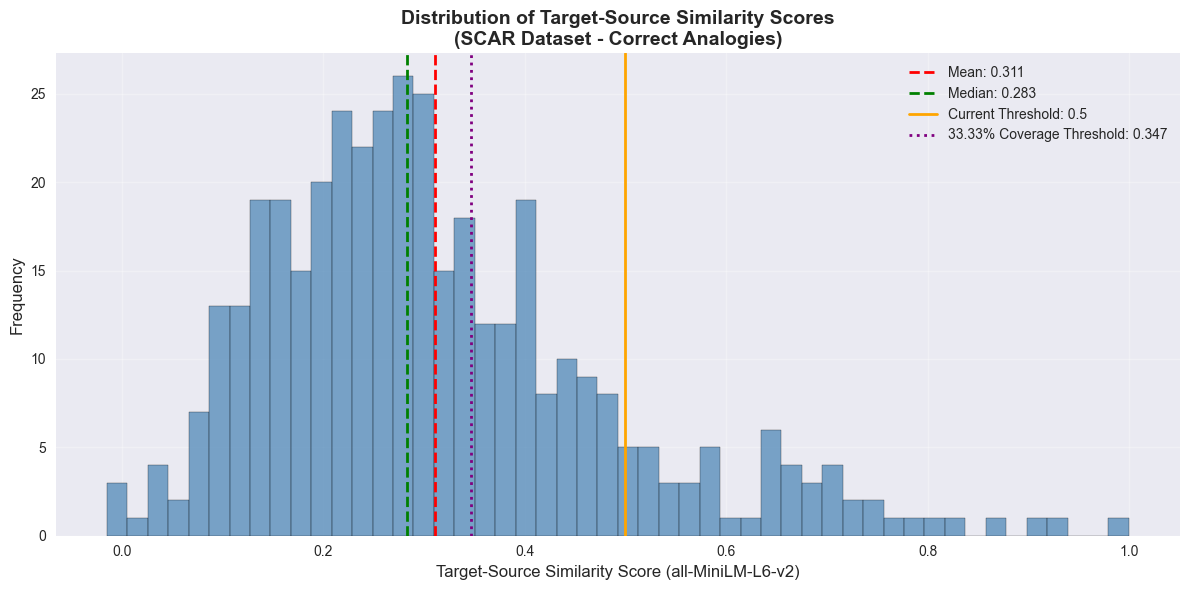

In [43]:
# Visualization 1: Distribution histogram
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(scar_sim_df['similarity'], bins=50, alpha=0.7, edgecolor='black', color='steelblue')
ax.axvline(scar_sim_df['similarity'].mean(), color='red', linestyle='--', linewidth=2, 
          label=f'Mean: {scar_sim_df["similarity"].mean():.3f}')
ax.axvline(scar_sim_df['similarity'].median(), color='green', linestyle='--', linewidth=2, 
          label=f'Median: {scar_sim_df["similarity"].median():.3f}')

# Add current threshold line
# SIMILARITY_THRESHOLD is already imported from core.config in cell 0
ax.axvline(SIMILARITY_THRESHOLD, color='orange', linestyle='-', linewidth=2, 
          label=f'Current Threshold: {SIMILARITY_THRESHOLD}')

# Add 33.33% coverage threshold (top third of dataset)
threshold_33 = scar_sim_df['similarity'].quantile(0.6667)  # 66.67th percentile = top 33.33%
ax.axvline(threshold_33, color='purple', linestyle=':', linewidth=2, 
          label=f'33.33% Coverage Threshold: {threshold_33:.3f}')

ax.set_xlabel('Target-Source Similarity Score (all-MiniLM-L6-v2)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Target-Source Similarity Scores\n(SCAR Dataset - Correct Analogies)', 
            fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'scar_target_source_similarity_distribution.png'), 
           dpi=300, bbox_inches='tight')
print("Saved: scar_target_source_similarity_distribution.png")
plt.show()


Saved: scar_target_source_similarity_cdf.png

Percentage of correct analogies above threshold 0.5: 12.00%


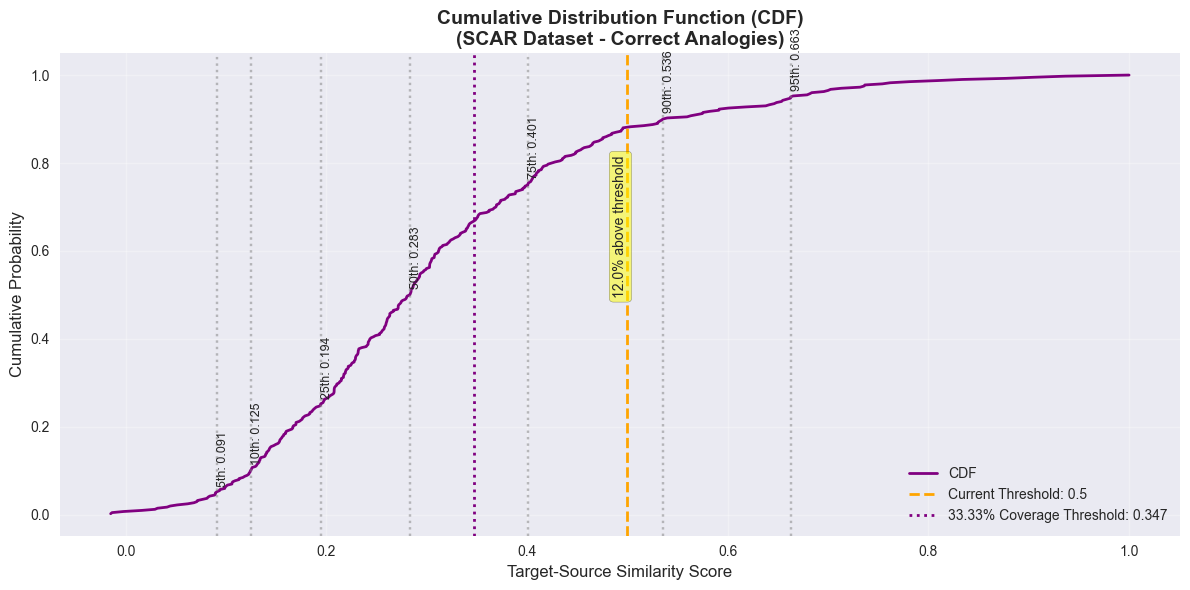

In [10]:
# Visualization 2: Cumulative Distribution Function (CDF)
fig, ax = plt.subplots(figsize=(12, 6))

sorted_scores = np.sort(scar_sim_df['similarity'])
cumulative = np.arange(1, len(sorted_scores) + 1) / len(sorted_scores)
ax.plot(sorted_scores, cumulative, linewidth=2, color='purple', label='CDF')

# Add percentile markers
percentiles = [5, 10, 25, 50, 75, 90, 95]
for p in percentiles:
    val = scar_sim_df['similarity'].quantile(p/100)
    ax.axvline(val, color='gray', linestyle=':', alpha=0.5)
    ax.text(val, 0.02 + (p/100), f'{p}th: {val:.3f}', rotation=90, fontsize=9)

# Add current threshold
ax.axvline(SIMILARITY_THRESHOLD, color='orange', linestyle='--', linewidth=2, 
          label=f'Current Threshold: {SIMILARITY_THRESHOLD}')

# Add 33.33% coverage threshold (top third of dataset)
threshold_33 = scar_sim_df['similarity'].quantile(0.6667)  # 66.67th percentile = top 33.33%
ax.axvline(threshold_33, color='purple', linestyle=':', linewidth=2, 
          label=f'33.33% Coverage Threshold: {threshold_33:.3f}')

# Calculate what percentage of correct analogies are above threshold
above_threshold = (scar_sim_df['similarity'] >= SIMILARITY_THRESHOLD).sum()
pct_above = (above_threshold / len(scar_sim_df)) * 100
ax.text(SIMILARITY_THRESHOLD, 0.5, f'{pct_above:.1f}% above threshold', 
       rotation=90, fontsize=10, ha='right', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

ax.set_xlabel('Target-Source Similarity Score', fontsize=12)
ax.set_ylabel('Cumulative Probability', fontsize=12)
ax.set_title('Cumulative Distribution Function (CDF)\n(SCAR Dataset - Correct Analogies)', 
            fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'scar_target_source_similarity_cdf.png'), 
           dpi=300, bbox_inches='tight')
print("Saved: scar_target_source_similarity_cdf.png")
print(f"\nPercentage of correct analogies above threshold {SIMILARITY_THRESHOLD}: {pct_above:.2f}%")
plt.show()


Saved: scar_target_source_similarity_boxplot.png


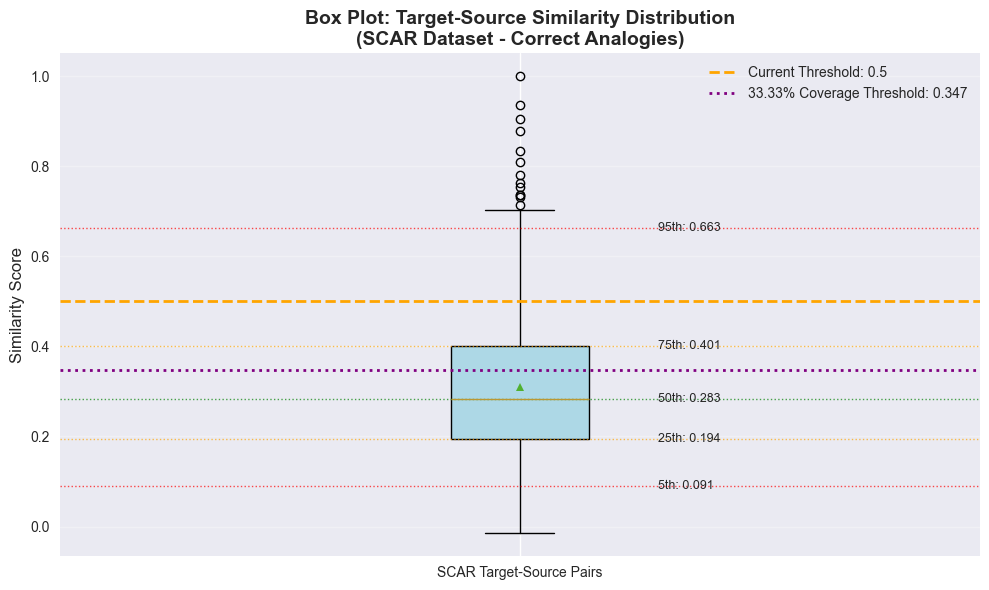

In [11]:
# Visualization 3: Box plot with percentile markers
fig, ax = plt.subplots(figsize=(10, 6))

bp = ax.boxplot([scar_sim_df['similarity']], labels=['SCAR Target-Source Pairs'], 
               patch_artist=True, showmeans=True)
bp['boxes'][0].set_facecolor('lightblue')

# Add percentile lines
percentiles = [5, 25, 50, 75, 95]
colors_p = ['red', 'orange', 'green', 'orange', 'red']
for p, color in zip(percentiles, colors_p):
    val = scar_sim_df['similarity'].quantile(p/100)
    ax.axhline(val, color=color, linestyle=':', alpha=0.7, linewidth=1)
    ax.text(1.15, val, f'{p}th: {val:.3f}', fontsize=9, va='center')

# Add current threshold
ax.axhline(SIMILARITY_THRESHOLD, color='orange', linestyle='--', linewidth=2, 
          label=f'Current Threshold: {SIMILARITY_THRESHOLD}')

# Add 33.33% coverage threshold (top third of dataset)
threshold_33 = scar_sim_df['similarity'].quantile(0.6667)  # 66.67th percentile = top 33.33%
ax.axhline(threshold_33, color='purple', linestyle=':', linewidth=2, 
          label=f'33.33% Coverage Threshold: {threshold_33:.3f}')

ax.set_ylabel('Similarity Score', fontsize=12)
ax.set_title('Box Plot: Target-Source Similarity Distribution\n(SCAR Dataset - Correct Analogies)', 
            fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'scar_target_source_similarity_boxplot.png'), 
           dpi=300, bbox_inches='tight')
print("Saved: scar_target_source_similarity_boxplot.png")
plt.show()


Saved: scar_threshold_analysis.png


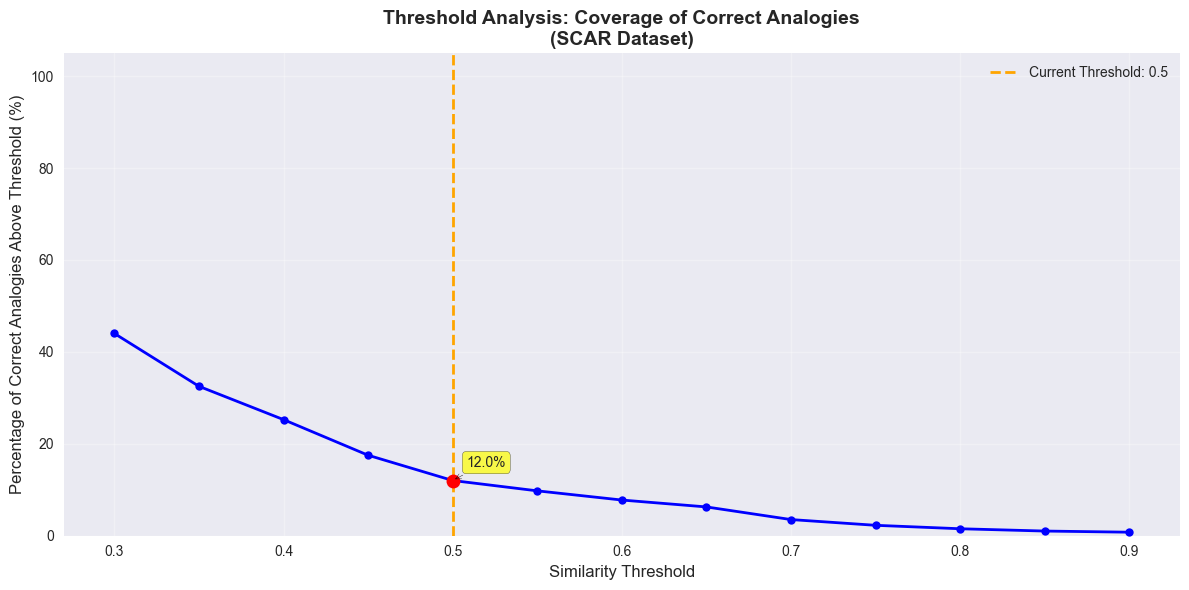


Threshold Recommendations Based on SCAR Dataset

Current threshold: 0.5
Coverage at current threshold: 12.00% of correct analogies

Suggested thresholds for different coverage levels:


In [12]:
# Visualization 4: Threshold Analysis - What percentage of correct analogies are captured at different thresholds?
thresholds = np.arange(0.3, 0.95, 0.05)
threshold_stats = []

for threshold in thresholds:
    above = (scar_sim_df['similarity'] >= threshold).sum()
    pct = (above / len(scar_sim_df)) * 100
    threshold_stats.append({
        'threshold': threshold,
        'count_above': above,
        'percentage': pct
    })

threshold_df = pd.DataFrame(threshold_stats)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(threshold_df['threshold'], threshold_df['percentage'], 'o-', linewidth=2, markersize=6, color='blue')
ax.axvline(SIMILARITY_THRESHOLD, color='orange', linestyle='--', linewidth=2, 
          label=f'Current Threshold: {SIMILARITY_THRESHOLD}')

# Add annotation for current threshold
current_pct = threshold_df[threshold_df['threshold'] == SIMILARITY_THRESHOLD]
if len(current_pct) == 0:
    # Find closest
    closest_idx = (threshold_df['threshold'] - SIMILARITY_THRESHOLD).abs().idxmin()
    current_pct = threshold_df.iloc[[closest_idx]]
if len(current_pct) > 0:
    pct_val = current_pct['percentage'].values[0]
    ax.plot(SIMILARITY_THRESHOLD, pct_val, 'ro', markersize=10)
    ax.annotate(f'{pct_val:.1f}%', 
               xy=(SIMILARITY_THRESHOLD, pct_val),
               xytext=(10, 10), textcoords='offset points',
               bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7),
               arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

ax.set_xlabel('Similarity Threshold', fontsize=12)
ax.set_ylabel('Percentage of Correct Analogies Above Threshold (%)', fontsize=12)
ax.set_title('Threshold Analysis: Coverage of Correct Analogies\n(SCAR Dataset)', 
            fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim([0, 105])

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'scar_threshold_analysis.png'), 
           dpi=300, bbox_inches='tight')
print("Saved: scar_threshold_analysis.png")
plt.show()

# Print threshold recommendations
print("\n" + "=" * 70)
print("Threshold Recommendations Based on SCAR Dataset")
print("=" * 70)
print(f"\nCurrent threshold: {SIMILARITY_THRESHOLD}")
current_coverage = threshold_df[threshold_df['threshold'] == SIMILARITY_THRESHOLD]
if len(current_coverage) == 0:
    closest_idx = (threshold_df['threshold'] - SIMILARITY_THRESHOLD).abs().idxmin()
    current_coverage = threshold_df.iloc[[closest_idx]]
if len(current_coverage) > 0:
    print(f"Coverage at current threshold: {current_coverage['percentage'].values[0]:.2f}% of correct analogies")

print(f"\nSuggested thresholds for different coverage levels:")
for coverage in [90, 80, 70, 60, 50]:
    # Find threshold that gives at least this coverage
    above_coverage = threshold_df[threshold_df['percentage'] >= coverage]
    if len(above_coverage) > 0:
        suggested_threshold = above_coverage['threshold'].max()
        print(f"  {coverage}% coverage: threshold >= {suggested_threshold:.3f}")


## Recalculated Target-Source Similarity: Visualizations

Visualizations for the recalculated method (averaging sources per target, then averaging all targets).

Saved: scar_target_source_similarity_recalculated_distribution.png


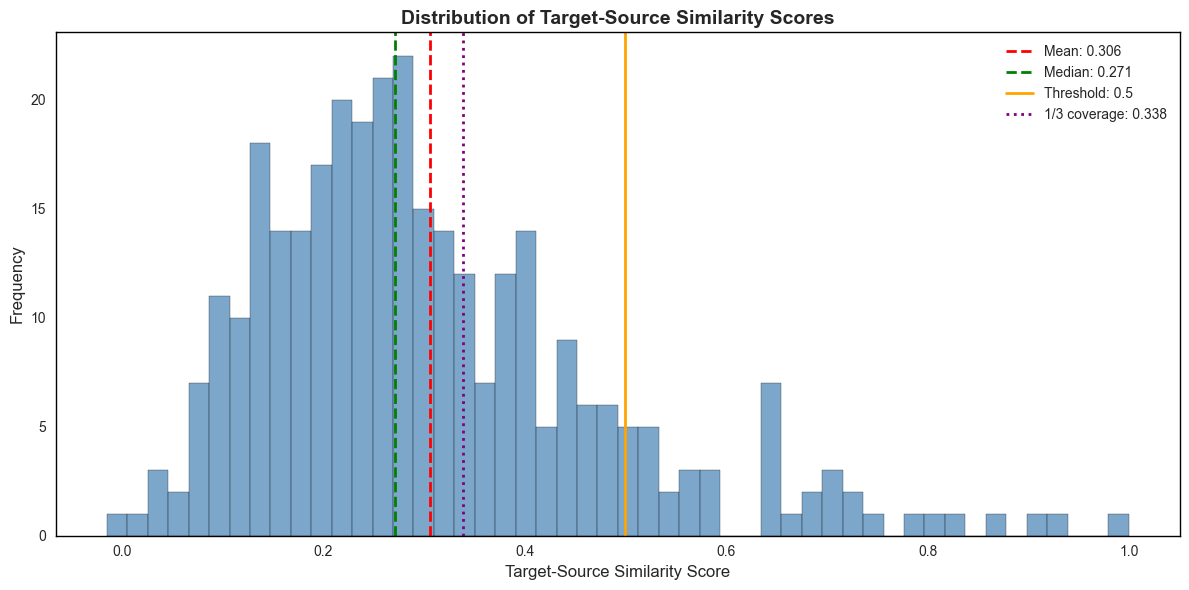

In [51]:
# Visualization: Recalculated Method - Distribution histogram
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('white')  # Set figure background to white
ax.set_facecolor('white')  # Set axes background to white

ax.hist(scar_sim_df_recalculated['avg_similarity'], bins=50, alpha=0.7, edgecolor='black', color='steelblue')
ax.axvline(scar_sim_df_recalculated['avg_similarity'].mean(), color='red', linestyle='--', linewidth=2, 
          label=f'Mean: {scar_sim_df_recalculated["avg_similarity"].mean():.3f}')
ax.axvline(scar_sim_df_recalculated['avg_similarity'].median(), color='green', linestyle='--', linewidth=2, 
          label=f'Median: {scar_sim_df_recalculated["avg_similarity"].median():.3f}')

# Add current threshold line
# SIMILARITY_THRESHOLD is already imported from core.config in cell 0
ax.axvline(SIMILARITY_THRESHOLD, color='orange', linestyle='-', linewidth=2, 
          label=f'Threshold: {SIMILARITY_THRESHOLD}')

# Add 33.33% coverage threshold (top third of dataset)
threshold_33_recalc = scar_sim_df_recalculated['avg_similarity'].quantile(0.6667)  # 66.67th percentile = top 33.33%
ax.axvline(threshold_33_recalc, color='purple', linestyle=':', linewidth=2, 
          label=f'1/3 coverage: {threshold_33_recalc:.3f}')

# Set axis spines (lines) to black
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['top'].set_color('black')
ax.spines['right'].set_color('black')
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.spines['top'].set_linewidth(1)
ax.spines['right'].set_linewidth(1)

ax.set_xlabel('Target-Source Similarity Score', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Target-Source Similarity Scores', 
            fontsize=14, fontweight='bold')
ax.legend()
# No grid - removed ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'scar_target_source_similarity_recalculated_distribution.png'), 
           dpi=300, bbox_inches='tight', facecolor='white')
print("Saved: scar_target_source_similarity_recalculated_distribution.png")
plt.show()

Saved: scar_target_source_original_vs_recalculated_comparison.png


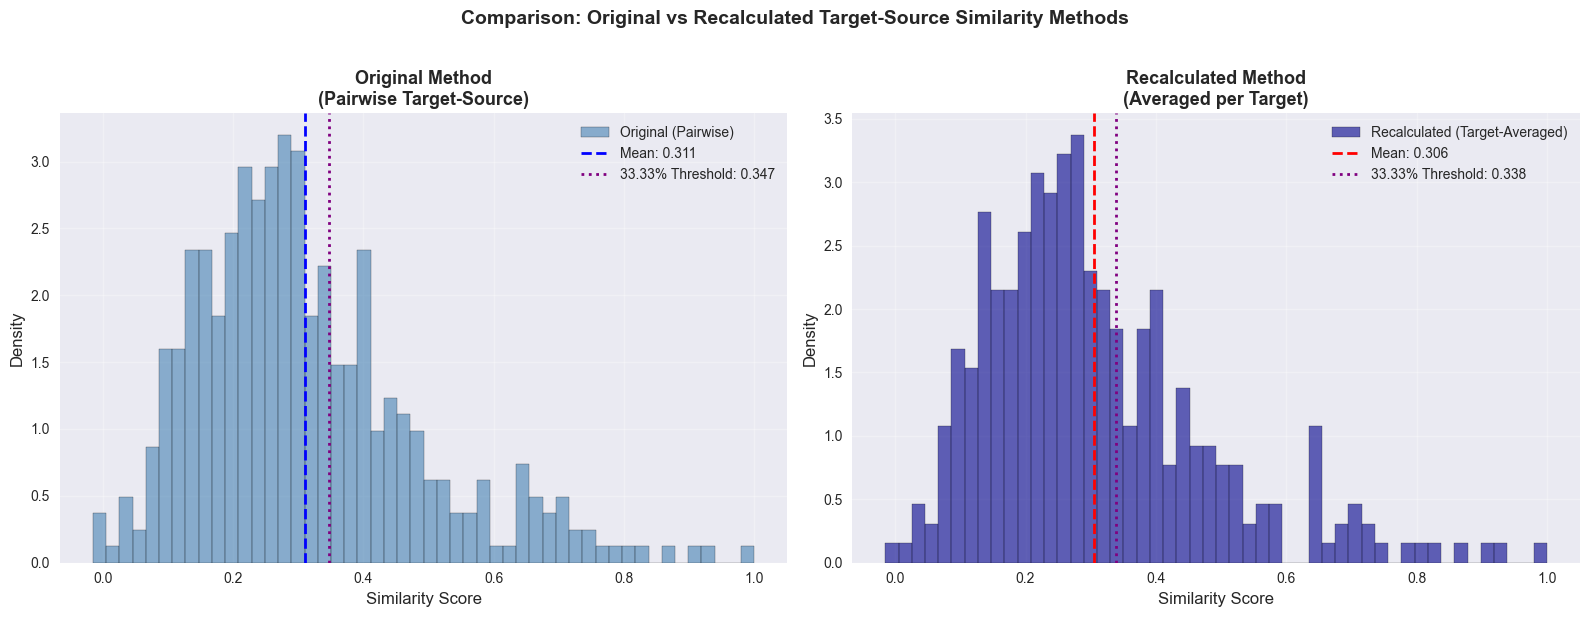


Comparison: Original vs Recalculated Method

Original method (pairwise):
  Mean: 0.3109
  Median: 0.2832
  33.33% threshold: 0.3466
  Count: 400 pairs

Recalculated method (target-averaged):
  Mean: 0.3057
  Median: 0.2715
  33.33% threshold: 0.3384
  Count: 321 targets

Difference in means: -0.0052
Difference in 33.33% thresholds: -0.0082


In [14]:
# Visualization: Comparison - Original vs Recalculated Method
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Original method (pairwise)
ax1 = axes[0]
ax1.hist(scar_sim_df['similarity'], bins=50, alpha=0.6, edgecolor='black', color='steelblue', 
        label='Original (Pairwise)', density=True)
ax1.axvline(scar_sim_df['similarity'].mean(), color='blue', linestyle='--', linewidth=2, 
           label=f'Mean: {scar_sim_df["similarity"].mean():.3f}')
threshold_33_orig = scar_sim_df['similarity'].quantile(0.6667)
ax1.axvline(threshold_33_orig, color='purple', linestyle=':', linewidth=2, 
           label=f'33.33% Threshold: {threshold_33_orig:.3f}')
ax1.set_xlabel('Similarity Score', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title('Original Method\n(Pairwise Target-Source)', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Right: Recalculated method (target-averaged)
ax2 = axes[1]
ax2.hist(scar_sim_df_recalculated['avg_similarity'], bins=50, alpha=0.6, edgecolor='black', color='darkblue', 
        label='Recalculated (Target-Averaged)', density=True)
ax2.axvline(scar_sim_df_recalculated['avg_similarity'].mean(), color='red', linestyle='--', linewidth=2, 
           label=f'Mean: {scar_sim_df_recalculated["avg_similarity"].mean():.3f}')
threshold_33_recalc = scar_sim_df_recalculated['avg_similarity'].quantile(0.6667)
ax2.axvline(threshold_33_recalc, color='purple', linestyle=':', linewidth=2, 
           label=f'33.33% Threshold: {threshold_33_recalc:.3f}')
ax2.set_xlabel('Similarity Score', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('Recalculated Method\n(Averaged per Target)', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

fig.suptitle('Comparison: Original vs Recalculated Target-Source Similarity Methods', 
            fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'scar_target_source_original_vs_recalculated_comparison.png'), 
           dpi=300, bbox_inches='tight')
print("Saved: scar_target_source_original_vs_recalculated_comparison.png")
plt.show()

# Print comparison statistics
print("\n" + "=" * 70)
print("Comparison: Original vs Recalculated Method")
print("=" * 70)
print(f"\nOriginal method (pairwise):")
print(f"  Mean: {scar_sim_df['similarity'].mean():.4f}")
print(f"  Median: {scar_sim_df['similarity'].median():.4f}")
print(f"  33.33% threshold: {threshold_33_orig:.4f}")
print(f"  Count: {len(scar_sim_df)} pairs")

print(f"\nRecalculated method (target-averaged):")
print(f"  Mean: {scar_sim_df_recalculated['avg_similarity'].mean():.4f}")
print(f"  Median: {scar_sim_df_recalculated['avg_similarity'].median():.4f}")
print(f"  33.33% threshold: {threshold_33_recalc:.4f}")
print(f"  Count: {len(scar_sim_df_recalculated)} targets")

print(f"\nDifference in means: {scar_sim_df_recalculated['avg_similarity'].mean() - scar_sim_df['similarity'].mean():.4f}")
print(f"Difference in 33.33% thresholds: {threshold_33_recalc - threshold_33_orig:.4f}")

In [15]:
# Save SCAR similarity data
scar_output_path = os.path.join(output_dir, 'scar_target_source_similarities.csv')
scar_sim_df.to_csv(scar_output_path, index=False)
print(f"Saved SCAR similarity data to: {scar_output_path}")

# Save threshold analysis
threshold_output_path = os.path.join(output_dir, 'scar_threshold_analysis.csv')
threshold_df.to_csv(threshold_output_path, index=False)
print(f"Saved threshold analysis to: {threshold_output_path}")

print("\n" + "=" * 70)
print("SCAR Dataset Analysis Complete!")
print("=" * 70)


Saved SCAR similarity data to: d:\My_working_area\Masters\Thesis\code\Toward-Usable-Scientific-Analogies\Toward-Usable-Scientific-Analogies\stage_2_Modular_solution\LLM\results\similarity_analysis\scar_target_source_similarities.csv
Saved threshold analysis to: d:\My_working_area\Masters\Thesis\code\Toward-Usable-Scientific-Analogies\Toward-Usable-Scientific-Analogies\stage_2_Modular_solution\LLM\results\similarity_analysis\scar_threshold_analysis.csv

SCAR Dataset Analysis Complete!


## SCAR Multi-Source Analysis: Source-to-Source Similarity

This section analyzes targets that have multiple gold sources. We compute source-to-source similarity to simulate the evaluation scenario where we compare generated analogies against gold sources. This helps understand what similarity scores look like when comparing sources (like generated vs gold).


In [16]:
# Find targets with multiple sources and compute source-to-source similarity
print("=" * 70)
print("SCAR Multi-Source Analysis: Source-to-Source Similarity")
print("=" * 70)

# Group by target to find those with multiple sources
target_groups = scar_df.groupby('system_a')['system_b'].apply(list).reset_index()
target_groups.columns = ['target', 'sources']
target_groups['num_sources'] = target_groups['sources'].apply(len)

# Filter to targets with multiple sources
multi_source_targets = target_groups[target_groups['num_sources'] > 1].copy()
print(f"\nTotal targets: {len(target_groups)}")
print(f"Targets with multiple sources: {len(multi_source_targets)}")
print(f"Average sources per multi-source target: {multi_source_targets['num_sources'].mean():.2f}")
print(f"Max sources for a single target: {multi_source_targets['num_sources'].max()}")

# Compute source-to-source similarity for each target with multiple sources
print(f"\nComputing source-to-source similarity using {EMBEDDING_MODEL}...")
print("This simulates the evaluation scenario: comparing sources (like generated vs gold)...")

source_to_source_similarities = []

for idx, row in multi_source_targets.iterrows():
    target = row['target']
    sources = [str(s).strip() for s in row['sources'] if str(s).strip() and str(s) != 'nan']
    
    if len(sources) < 2:
        continue
    
    # Compute pairwise similarity between all sources for this target
    for i, source1 in enumerate(sources):
        for j, source2 in enumerate(sources):
            if i < j:  # Only compute each pair once
                try:
                    # Compute similarity using all-MiniLM-L6-v2
                    source1_emb = embedder.encode([source1.lower()])[0]
                    source2_emb = embedder.encode([source2.lower()])[0]
                    
                    similarity = np.dot(source1_emb, source2_emb) / (
                        np.linalg.norm(source1_emb) * np.linalg.norm(source2_emb) + 1e-8
                    )
                    
                    source_to_source_similarities.append({
                        'target': target,
                        'source1': source1,
                        'source2': source2,
                        'similarity': float(similarity),
                        'num_sources_for_target': len(sources)
                    })
                except Exception as e:
                    print(f"Error processing {target}: {e}")
                    continue
    
    if (idx + 1) % 50 == 0:
        print(f"  Processed {idx + 1}/{len(multi_source_targets)} targets...")

source_sim_df = pd.DataFrame(source_to_source_similarities)
print(f"\nComputed {len(source_sim_df)} source-to-source similarity pairs")

# Statistics
print("\n" + "=" * 70)
print("Source-to-Source Similarity Statistics")
print("=" * 70)
print(f"Total source pairs: {len(source_sim_df)}")
print(f"Mean similarity: {source_sim_df['similarity'].mean():.4f}")
print(f"Median similarity: {source_sim_df['similarity'].median():.4f}")
print(f"Std deviation: {source_sim_df['similarity'].std():.4f}")
print(f"Min similarity: {source_sim_df['similarity'].min():.4f}")
print(f"Max similarity: {source_sim_df['similarity'].max():.4f}")
print(f"\nPercentiles:")
for p in [5, 10, 25, 50, 75, 90, 95]:
    val = source_sim_df['similarity'].quantile(p/100)
    print(f"  {p}th percentile: {val:.4f}")

# Compare with current threshold
above_threshold = (source_sim_df['similarity'] >= SIMILARITY_THRESHOLD).sum()
pct_above = (above_threshold / len(source_sim_df)) * 100
print(f"\nPairs above threshold {SIMILARITY_THRESHOLD}: {above_threshold}/{len(source_sim_df)} ({pct_above:.2f}%)")


SCAR Multi-Source Analysis: Source-to-Source Similarity

Total targets: 321
Targets with multiple sources: 55
Average sources per multi-source target: 2.44
Max sources for a single target: 11

Computing source-to-source similarity using all-MiniLM-L6-v2...
This simulates the evaluation scenario: comparing sources (like generated vs gold)...



Computed 145 source-to-source similarity pairs

Source-to-Source Similarity Statistics
Total source pairs: 145
Mean similarity: 0.3685
Median similarity: 0.3226
Std deviation: 0.2255
Min similarity: 0.0078
Max similarity: 1.0000

Percentiles:
  5th percentile: 0.1163
  10th percentile: 0.1575
  25th percentile: 0.2247
  50th percentile: 0.3226
  75th percentile: 0.3956
  90th percentile: 0.7025
  95th percentile: 1.0000

Pairs above threshold 0.5: 27/145 (18.62%)


Saved: scar_source_to_source_similarity_distribution.png


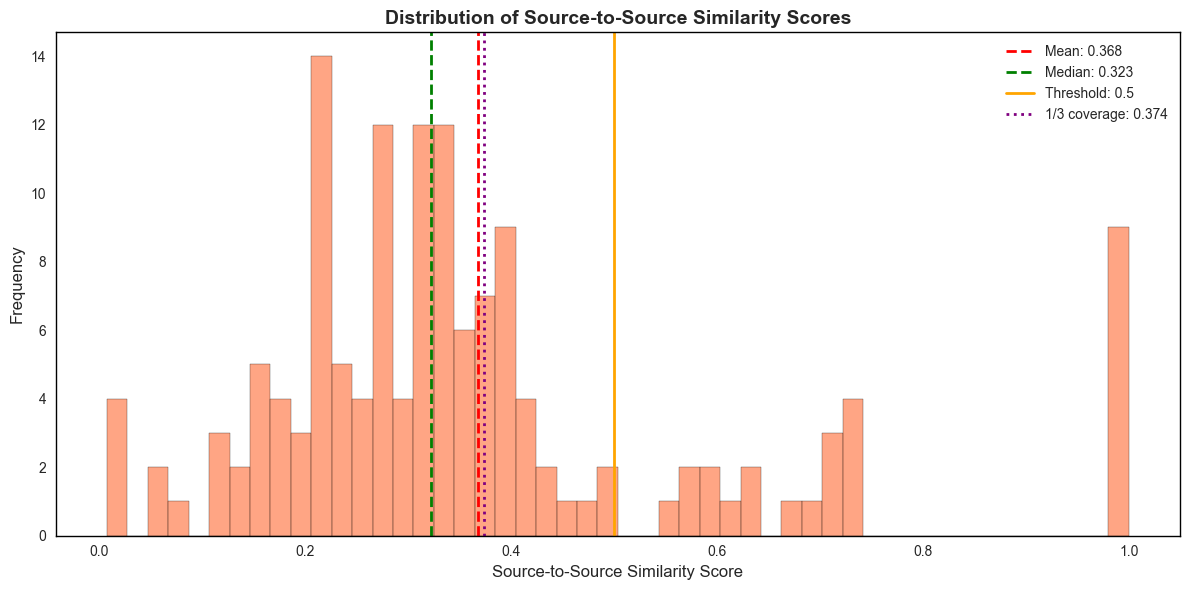

In [50]:
# # Visualization 1: Distribution histogram of source-to-source similarity
# fig, ax = plt.subplots(figsize=(12, 6))

# ax.hist(source_sim_df['similarity'], bins=50, alpha=0.7, edgecolor='black', color='coral')
# ax.axvline(source_sim_df['similarity'].mean(), color='red', linestyle='--', linewidth=2, 
#           label=f'Mean: {source_sim_df["similarity"].mean():.3f}')
# ax.axvline(source_sim_df['similarity'].median(), color='green', linestyle='--', linewidth=2, 
#           label=f'Median: {source_sim_df["similarity"].median():.3f}')

# # Add current threshold line
# ax.axvline(SIMILARITY_THRESHOLD, color='orange', linestyle='-', linewidth=2, 
#           label=f'Current Threshold: {SIMILARITY_THRESHOLD}')

# # Add 33.33% coverage threshold (top third of dataset)
# threshold_33_source = source_sim_df['similarity'].quantile(0.6667)  # 66.67th percentile = top 33.33%
# ax.axvline(threshold_33_source, color='purple', linestyle=':', linewidth=2, 
#           label=f'33.33% Coverage Threshold: {threshold_33_source:.3f}')

# ax.set_xlabel('Source-to-Source Similarity Score', fontsize=12)
# ax.set_ylabel('Frequency', fontsize=12)
# ax.set_title('Distribution of Source-to-Source Similarity Scores', 
#             fontsize=14, fontweight='bold')
# ax.legend()
# ax.grid(alpha=0.3)

# plt.tight_layout()
# plt.savefig(os.path.join(output_dir, 'scar_source_to_source_similarity_distribution.png'), 
#            dpi=300, bbox_inches='tight')
# print("Saved: scar_source_to_source_similarity_distribution.png")
# plt.show()
# Visualization 1: Distribution histogram of source-to-source similarity
# fig, ax = plt.subplots(figsize=(12, 6))
# fig.patch.set_facecolor('white')  # Set figure background to white
# ax.set_facecolor('white')  # Set axes background to white

# ax.hist(source_sim_df['similarity'], bins=50, alpha=0.7, edgecolor='black', color='coral')
# ax.axvline(source_sim_df['similarity'].mean(), color='red', linestyle='--', linewidth=2, 
#           label=f'Mean: {source_sim_df["similarity"].mean():.3f}')
# ax.axvline(source_sim_df['similarity'].median(), color='green', linestyle='--', linewidth=2, 
#           label=f'Median: {source_sim_df["similarity"].median():.3f}')

# # Add current threshold line
# ax.axvline(SIMILARITY_THRESHOLD, color='orange', linestyle='-', linewidth=2, 
#           label=f'Current Threshold: {SIMILARITY_THRESHOLD}')

# # Add 33.33% coverage threshold (top third of dataset)
# threshold_33_source = source_sim_df['similarity'].quantile(0.6667)  # 66.67th percentile = top 33.33%
# ax.axvline(threshold_33_source, color='purple', linestyle=':', linewidth=2, 
#           label=f'1/3 Coverage Threshold: {threshold_33_source:.3f}')

# ax.set_xlabel('Source-to-Source Similarity Score', fontsize=12)
# ax.set_ylabel('Frequency', fontsize=12)
# ax.set_title('Distribution of Source-to-Source Similarity Scores', 
#             fontsize=14, fontweight='bold')
# ax.legend()
# # Remove grid - changed from ax.grid(alpha=0.3) to no grid
# # Axes are shown by default (spines are visible)

# plt.tight_layout()
# plt.savefig(os.path.join(output_dir, 'scar_source_to_source_similarity_distribution.png'), 
#            dpi=300, bbox_inches='tight', facecolor='white')  # Also set facecolor in savefig
# print("Saved: scar_source_to_source_similarity_distribution.png")
# plt.show()

# Visualization 1: Distribution histogram of source-to-source similarity
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('white')  # Set figure background to white
ax.set_facecolor('white')  # Set axes background to white

ax.hist(source_sim_df['similarity'], bins=50, alpha=0.7, edgecolor='black', color='coral')
ax.axvline(source_sim_df['similarity'].mean(), color='red', linestyle='--', linewidth=2, 
          label=f'Mean: {source_sim_df["similarity"].mean():.3f}')
ax.axvline(source_sim_df['similarity'].median(), color='green', linestyle='--', linewidth=2, 
          label=f'Median: {source_sim_df["similarity"].median():.3f}')

# Add current threshold line
ax.axvline(SIMILARITY_THRESHOLD, color='orange', linestyle='-', linewidth=2, 
          label=f'Threshold: {SIMILARITY_THRESHOLD}')

# Add 33.33% coverage threshold (top third of dataset)
threshold_33_source = source_sim_df['similarity'].quantile(0.6667)  # 66.67th percentile = top 33.33%
ax.axvline(threshold_33_source, color='purple', linestyle=':', linewidth=2, 
          label=f'1/3 coverage: {threshold_33_source:.3f}')

# Set axis spines (lines) to black
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['top'].set_color('black')
ax.spines['right'].set_color('black')
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.spines['top'].set_linewidth(1)
ax.spines['right'].set_linewidth(1)

ax.set_xlabel('Source-to-Source Similarity Score', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Source-to-Source Similarity Scores', 
            fontsize=14, fontweight='bold')
ax.legend()
# No grid

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'scar_source_to_source_similarity_distribution.png'), 
           dpi=300, bbox_inches='tight', facecolor='white')
print("Saved: scar_source_to_source_similarity_distribution.png")
plt.show()

Saved: scar_source_to_source_similarity_cdf.png

Percentage of source pairs above threshold 0.5: 18.62%


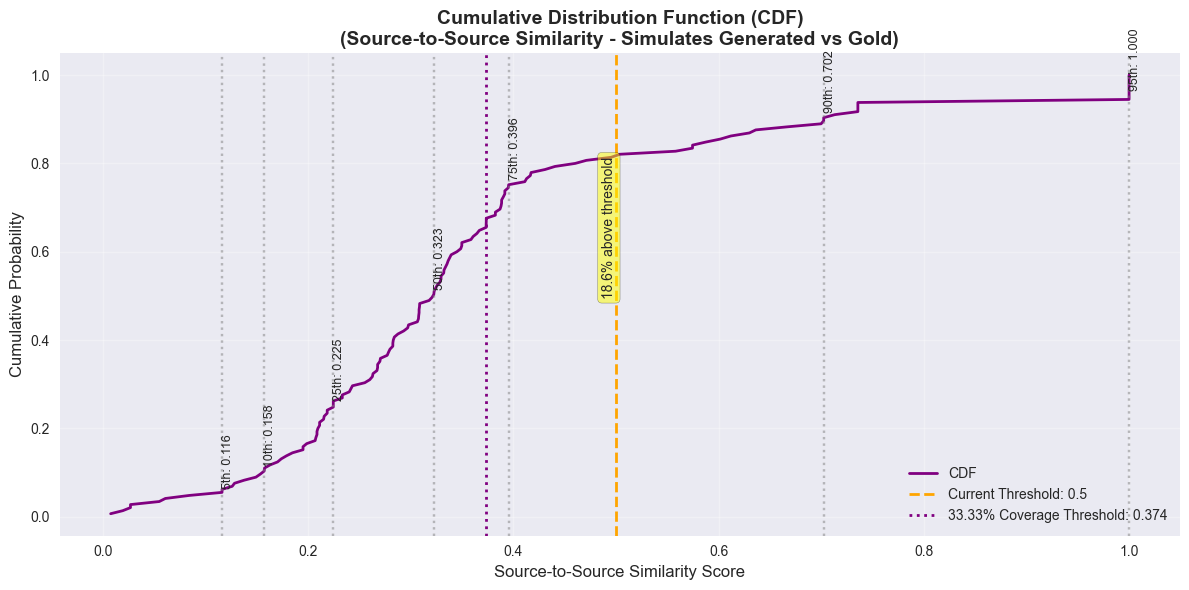

In [18]:
# Visualization 2: CDF of source-to-source similarity
fig, ax = plt.subplots(figsize=(12, 6))

sorted_scores = np.sort(source_sim_df['similarity'])
cumulative = np.arange(1, len(sorted_scores) + 1) / len(sorted_scores)
ax.plot(sorted_scores, cumulative, linewidth=2, color='purple', label='CDF')

# Add percentile markers
percentiles = [5, 10, 25, 50, 75, 90, 95]
for p in percentiles:
    val = source_sim_df['similarity'].quantile(p/100)
    ax.axvline(val, color='gray', linestyle=':', alpha=0.5)
    ax.text(val, 0.02 + (p/100), f'{p}th: {val:.3f}', rotation=90, fontsize=9)

# Add current threshold
ax.axvline(SIMILARITY_THRESHOLD, color='orange', linestyle='--', linewidth=2, 
          label=f'Current Threshold: {SIMILARITY_THRESHOLD}')

# Add 33.33% coverage threshold (top third of dataset)
threshold_33_source = source_sim_df['similarity'].quantile(0.6667)  # 66.67th percentile = top 33.33%
ax.axvline(threshold_33_source, color='purple', linestyle=':', linewidth=2, 
          label=f'33.33% Coverage Threshold: {threshold_33_source:.3f}')

# Calculate what percentage are above threshold
above_threshold = (source_sim_df['similarity'] >= SIMILARITY_THRESHOLD).sum()
pct_above = (above_threshold / len(source_sim_df)) * 100
ax.text(SIMILARITY_THRESHOLD, 0.5, f'{pct_above:.1f}% above threshold', 
       rotation=90, fontsize=10, ha='right', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

ax.set_xlabel('Source-to-Source Similarity Score', fontsize=12)
ax.set_ylabel('Cumulative Probability', fontsize=12)
ax.set_title('Cumulative Distribution Function (CDF)\n(Source-to-Source Similarity - Simulates Generated vs Gold)', 
            fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'scar_source_to_source_similarity_cdf.png'), 
           dpi=300, bbox_inches='tight')
print("Saved: scar_source_to_source_similarity_cdf.png")
print(f"\nPercentage of source pairs above threshold {SIMILARITY_THRESHOLD}: {pct_above:.2f}%")
plt.show()


Saved: scar_target_source_vs_source_source_comparison.png


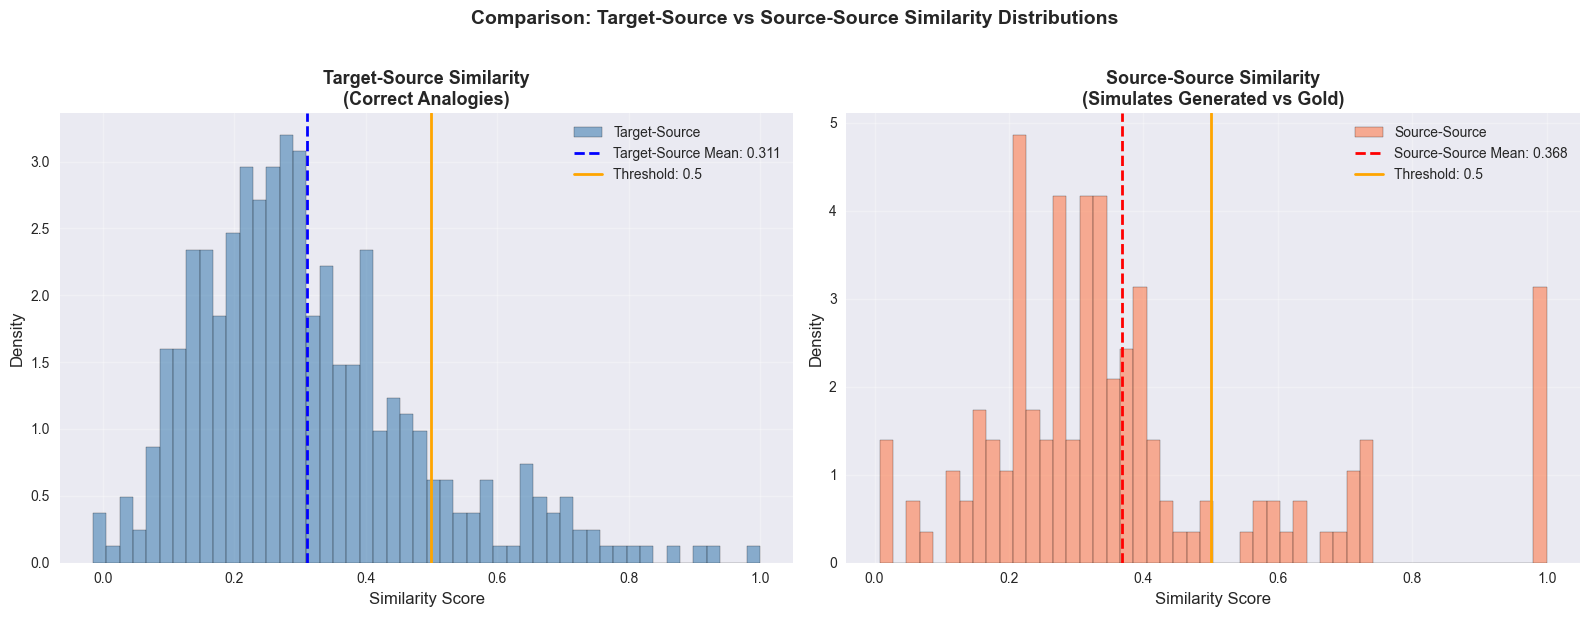


Comparison: Target-Source vs Source-Source Similarity

Target-Source (correct analogies):
  Mean: 0.3109
  Median: 0.2832
  Std: 0.1729

Source-Source (simulates generated vs gold):
  Mean: 0.3685
  Median: 0.3226
  Std: 0.2255

Difference in means: 0.0576


In [19]:
# Visualization 3: Comparison - Target-Source vs Source-Source similarity
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Target-Source similarity (from SCAR analysis)
ax1 = axes[0]
ax1.hist(scar_sim_df['similarity'], bins=50, alpha=0.6, edgecolor='black', color='steelblue', 
        label='Target-Source', density=True)
ax1.axvline(scar_sim_df['similarity'].mean(), color='blue', linestyle='--', linewidth=2, 
           label=f'Target-Source Mean: {scar_sim_df["similarity"].mean():.3f}')
ax1.axvline(SIMILARITY_THRESHOLD, color='orange', linestyle='-', linewidth=2, 
           label=f'Threshold: {SIMILARITY_THRESHOLD}')
ax1.set_xlabel('Similarity Score', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title('Target-Source Similarity\n(Correct Analogies)', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Right: Source-Source similarity
ax2 = axes[1]
ax2.hist(source_sim_df['similarity'], bins=50, alpha=0.6, edgecolor='black', color='coral', 
        label='Source-Source', density=True)
ax2.axvline(source_sim_df['similarity'].mean(), color='red', linestyle='--', linewidth=2, 
           label=f'Source-Source Mean: {source_sim_df["similarity"].mean():.3f}')
ax2.axvline(SIMILARITY_THRESHOLD, color='orange', linestyle='-', linewidth=2, 
           label=f'Threshold: {SIMILARITY_THRESHOLD}')
ax2.set_xlabel('Similarity Score', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('Source-Source Similarity\n(Simulates Generated vs Gold)', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

fig.suptitle('Comparison: Target-Source vs Source-Source Similarity Distributions', 
            fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'scar_target_source_vs_source_source_comparison.png'), 
           dpi=300, bbox_inches='tight')
print("Saved: scar_target_source_vs_source_source_comparison.png")
plt.show()

# Print comparison statistics
print("\n" + "=" * 70)
print("Comparison: Target-Source vs Source-Source Similarity")
print("=" * 70)
print(f"\nTarget-Source (correct analogies):")
print(f"  Mean: {scar_sim_df['similarity'].mean():.4f}")
print(f"  Median: {scar_sim_df['similarity'].median():.4f}")
print(f"  Std: {scar_sim_df['similarity'].std():.4f}")

print(f"\nSource-Source (simulates generated vs gold):")
print(f"  Mean: {source_sim_df['similarity'].mean():.4f}")
print(f"  Median: {source_sim_df['similarity'].median():.4f}")
print(f"  Std: {source_sim_df['similarity'].std():.4f}")

print(f"\nDifference in means: {source_sim_df['similarity'].mean() - scar_sim_df['similarity'].mean():.4f}")


Saved: scar_similarity_comparison_boxplot.png


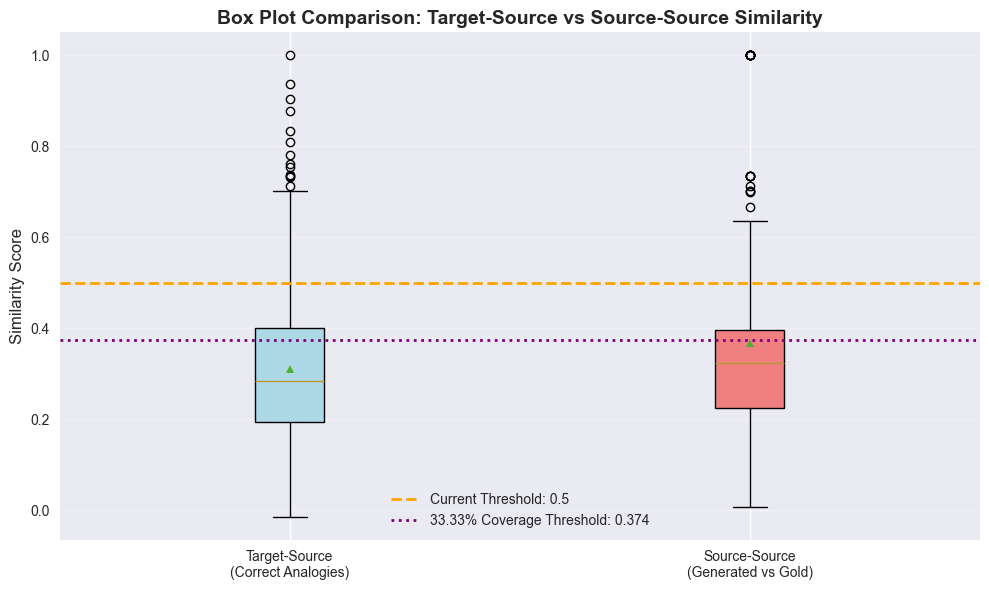

In [20]:
# Visualization 4: Box plot comparison
fig, ax = plt.subplots(figsize=(10, 6))

box_data = [scar_sim_df['similarity'].values, source_sim_df['similarity'].values]
bp = ax.boxplot(box_data, labels=['Target-Source\n(Correct Analogies)', 'Source-Source\n(Generated vs Gold)'], 
               patch_artist=True, showmeans=True)

# Color the boxes
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightcoral')

# Add current threshold
ax.axhline(SIMILARITY_THRESHOLD, color='orange', linestyle='--', linewidth=2, 
          label=f'Current Threshold: {SIMILARITY_THRESHOLD}')

# Add 33.33% coverage threshold (top third of dataset)
threshold_33_source = source_sim_df['similarity'].quantile(0.6667)  # 66.67th percentile = top 33.33%
ax.axhline(threshold_33_source, color='purple', linestyle=':', linewidth=2, 
          label=f'33.33% Coverage Threshold: {threshold_33_source:.3f}')


ax.set_ylabel('Similarity Score', fontsize=12)
ax.set_title('Box Plot Comparison: Target-Source vs Source-Source Similarity', 
            fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'scar_similarity_comparison_boxplot.png'), 
           dpi=300, bbox_inches='tight')
print("Saved: scar_similarity_comparison_boxplot.png")
plt.show()


Saved: scar_source_threshold_analysis.png


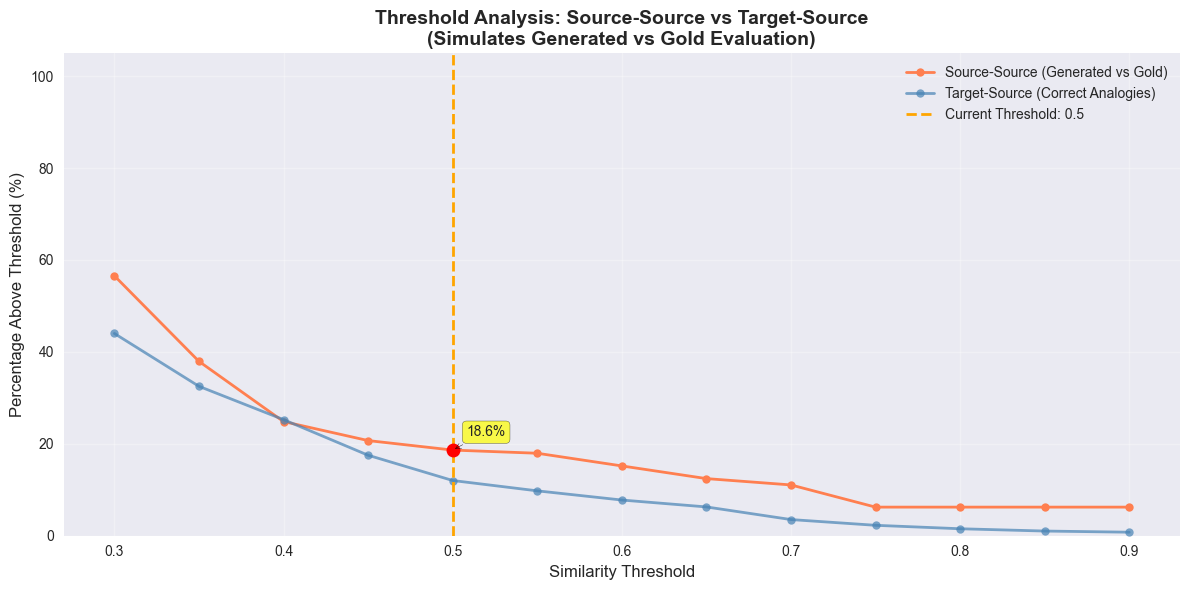


Threshold Recommendations for Source-Source (Generated vs Gold Scenario)

Current threshold: 0.5
Coverage at current threshold: 18.62% of source pairs

Suggested thresholds for different coverage levels (source-to-source):
  50% coverage: threshold >= 0.300


In [21]:
# Visualization 5: Threshold analysis for source-to-source (simulates generated vs gold scenario)
thresholds = np.arange(0.3, 0.95, 0.05)
source_threshold_stats = []

for threshold in thresholds:
    above = (source_sim_df['similarity'] >= threshold).sum()
    pct = (above / len(source_sim_df)) * 100
    source_threshold_stats.append({
        'threshold': threshold,
        'count_above': above,
        'percentage': pct
    })

source_threshold_df = pd.DataFrame(source_threshold_stats)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(source_threshold_df['threshold'], source_threshold_df['percentage'], 'o-', 
       linewidth=2, markersize=6, color='coral', label='Source-Source (Generated vs Gold)')

# Also plot target-source for comparison
ax.plot(threshold_df['threshold'], threshold_df['percentage'], 'o-', 
       linewidth=2, markersize=6, color='steelblue', label='Target-Source (Correct Analogies)', 
       alpha=0.7)

ax.axvline(SIMILARITY_THRESHOLD, color='orange', linestyle='--', linewidth=2, 
          label=f'Current Threshold: {SIMILARITY_THRESHOLD}')

# Add annotation for current threshold on source-source line
current_pct_source = source_threshold_df[source_threshold_df['threshold'] == SIMILARITY_THRESHOLD]
if len(current_pct_source) == 0:
    closest_idx = (source_threshold_df['threshold'] - SIMILARITY_THRESHOLD).abs().idxmin()
    current_pct_source = source_threshold_df.iloc[[closest_idx]]
if len(current_pct_source) > 0:
    pct_val = current_pct_source['percentage'].values[0]
    ax.plot(SIMILARITY_THRESHOLD, pct_val, 'ro', markersize=10)
    ax.annotate(f'{pct_val:.1f}%', 
               xy=(SIMILARITY_THRESHOLD, pct_val),
               xytext=(10, 10), textcoords='offset points',
               bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7),
               arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

ax.set_xlabel('Similarity Threshold', fontsize=12)
ax.set_ylabel('Percentage Above Threshold (%)', fontsize=12)
ax.set_title('Threshold Analysis: Source-Source vs Target-Source\n(Simulates Generated vs Gold Evaluation)', 
            fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim([0, 105])

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'scar_source_threshold_analysis.png'), 
           dpi=300, bbox_inches='tight')
print("Saved: scar_source_threshold_analysis.png")
plt.show()

# Print recommendations
print("\n" + "=" * 70)
print("Threshold Recommendations for Source-Source (Generated vs Gold Scenario)")
print("=" * 70)
print(f"\nCurrent threshold: {SIMILARITY_THRESHOLD}")
if len(current_pct_source) > 0:
    print(f"Coverage at current threshold: {current_pct_source['percentage'].values[0]:.2f}% of source pairs")

print(f"\nSuggested thresholds for different coverage levels (source-to-source):")
for coverage in [90, 80, 70, 60, 50]:
    above_coverage = source_threshold_df[source_threshold_df['percentage'] >= coverage]
    if len(above_coverage) > 0:
        suggested_threshold = above_coverage['threshold'].max()
        print(f"  {coverage}% coverage: threshold >= {suggested_threshold:.3f}")


Saved: scar_similarity_by_source_count.png


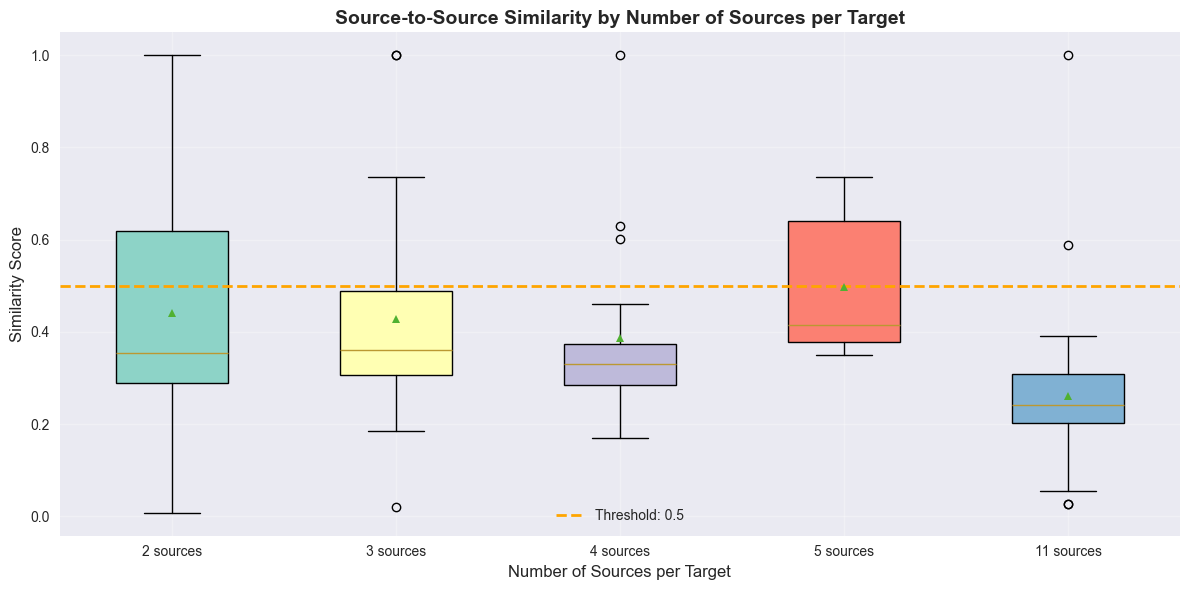


Source-to-Source Similarity Statistics by Number of Sources

2 sources per target (n=44 pairs):
  Mean: 0.4417
  Median: 0.3538
  Above threshold 0.5: 14/44 (31.8%)

3 sources per target (n=18 pairs):
  Mean: 0.4278
  Median: 0.3618
  Above threshold 0.5: 4/18 (22.2%)

4 sources per target (n=18 pairs):
  Mean: 0.3864
  Median: 0.3296
  Above threshold 0.5: 3/18 (16.7%)

5 sources per target (n=10 pairs):
  Mean: 0.4971
  Median: 0.4143
  Above threshold 0.5: 4/10 (40.0%)

11 sources per target (n=55 pairs):
  Mean: 0.2612
  Median: 0.2418
  Above threshold 0.5: 2/55 (3.6%)


In [22]:
# Visualization 6: Similarity by number of sources per target
# Group by number of sources and show distribution
fig, ax = plt.subplots(figsize=(12, 6))

# Get unique counts of sources
source_counts = source_sim_df['num_sources_for_target'].unique()
source_counts = sorted(source_counts)

# Create violin plot or box plot for each source count
if len(source_counts) <= 5:
    # Use box plot if few categories
    box_data = [source_sim_df[source_sim_df['num_sources_for_target'] == count]['similarity'].values 
                for count in source_counts]
    labels = [f'{count} sources' for count in source_counts]
    bp = ax.boxplot(box_data, labels=labels, patch_artist=True, showmeans=True)
    for patch, color in zip(bp['boxes'], plt.cm.Set3(range(len(box_data)))):
        patch.set_facecolor(color)
else:
    # Use histogram overlay if many categories
    for count in source_counts[:10]:  # Limit to first 10
        data = source_sim_df[source_sim_df['num_sources_for_target'] == count]['similarity']
        if len(data) > 0:
            ax.hist(data, bins=20, alpha=0.5, label=f'{count} sources (n={len(data)})', density=True)
    ax.legend()

ax.axhline(SIMILARITY_THRESHOLD, color='orange', linestyle='--', linewidth=2, 
          label=f'Threshold: {SIMILARITY_THRESHOLD}')

ax.set_xlabel('Number of Sources per Target' if len(source_counts) <= 5 else 'Similarity Score', fontsize=12)
ax.set_ylabel('Similarity Score' if len(source_counts) <= 5 else 'Density', fontsize=12)
ax.set_title('Source-to-Source Similarity by Number of Sources per Target', 
            fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'scar_similarity_by_source_count.png'), 
           dpi=300, bbox_inches='tight')
print("Saved: scar_similarity_by_source_count.png")
plt.show()

# Statistics by source count
print("\n" + "=" * 70)
print("Source-to-Source Similarity Statistics by Number of Sources")
print("=" * 70)
for count in sorted(source_counts)[:10]:  # Show first 10
    data = source_sim_df[source_sim_df['num_sources_for_target'] == count]['similarity']
    if len(data) > 0:
        print(f"\n{count} sources per target (n={len(data)} pairs):")
        print(f"  Mean: {data.mean():.4f}")
        print(f"  Median: {data.median():.4f}")
        print(f"  Above threshold {SIMILARITY_THRESHOLD}: {(data >= SIMILARITY_THRESHOLD).sum()}/{len(data)} ({(data >= SIMILARITY_THRESHOLD).sum()/len(data)*100:.1f}%)")


In [23]:
# Save source-to-source similarity data
source_output_path = os.path.join(output_dir, 'scar_source_to_source_similarities.csv')
source_sim_df.to_csv(source_output_path, index=False)
print(f"Saved source-to-source similarity data to: {source_output_path}")

# Save source threshold analysis
source_threshold_output_path = os.path.join(output_dir, 'scar_source_threshold_analysis.csv')
source_threshold_df.to_csv(source_threshold_output_path, index=False)
print(f"Saved source threshold analysis to: {source_threshold_output_path}")

print("\n" + "=" * 70)
print("SCAR Multi-Source Analysis Complete!")
print("=" * 70)
print("\nKey Insights:")
print(f"  - {len(multi_source_targets)} targets have multiple sources")
print(f"  - {len(source_sim_df)} source-to-source pairs analyzed")
print(f"  - Mean source-to-source similarity: {source_sim_df['similarity'].mean():.4f}")
print(f"  - This simulates the evaluation scenario (generated analogy vs gold source)")
print(f"  - Current threshold {SIMILARITY_THRESHOLD} captures {(source_sim_df['similarity'] >= SIMILARITY_THRESHOLD).sum()}/{len(source_sim_df)} pairs ({(source_sim_df['similarity'] >= SIMILARITY_THRESHOLD).sum()/len(source_sim_df)*100:.1f}%)")
print("=" * 70)


Saved source-to-source similarity data to: d:\My_working_area\Masters\Thesis\code\Toward-Usable-Scientific-Analogies\Toward-Usable-Scientific-Analogies\stage_2_Modular_solution\LLM\results\similarity_analysis\scar_source_to_source_similarities.csv
Saved source threshold analysis to: d:\My_working_area\Masters\Thesis\code\Toward-Usable-Scientific-Analogies\Toward-Usable-Scientific-Analogies\stage_2_Modular_solution\LLM\results\similarity_analysis\scar_source_threshold_analysis.csv

SCAR Multi-Source Analysis Complete!

Key Insights:
  - 55 targets have multiple sources
  - 145 source-to-source pairs analyzed
  - Mean source-to-source similarity: 0.3685
  - This simulates the evaluation scenario (generated analogy vs gold source)
  - Current threshold 0.5 captures 27/145 pairs (18.6%)


---

## Hit@1,2,3 Similarity Analysis

Now we analyze similarity scores for generated analogies that matched at Hit@1, 2, or 3 positions.


In [24]:
def extract_hit_similarity_scores(df):
    """
    Extract similarity scores for analogies at Hit@1, 2, 3 (exact matches only).
    
    Returns DataFrame with: rank, analogy, gold_analogy_similarity, target, model, mode
    """
    results = []
    
    for idx, row in df.iterrows():
        # Parse gold_ranks to get which analogies matched at which ranks
        gold_ranks = {}
        if pd.notna(row.get('gold_ranks')):
            try:
                gold_ranks = json.loads(row['gold_ranks'])
            except (json.JSONDecodeError, ValueError, TypeError):
                gold_ranks = {}
        
        # Parse similarity_per_gold to get similarity scores
        similarity_per_gold = {}
        if pd.notna(row.get('similarity_per_gold')):
            try:
                similarity_per_gold = json.loads(row['similarity_per_gold'])
            except (json.JSONDecodeError, ValueError, TypeError):
                similarity_per_gold = {}
        
        # Parse generated analogies
        generated_analogies = []
        if pd.notna(row.get('generated_analogies')):
            try:
                generated_analogies = json.loads(row['generated_analogies'])
            except (json.JSONDecodeError, ValueError, TypeError):
                generated_analogies = []
        
        target = row.get('target', '')
        model = row.get('model', '')
        mode = row.get('mode', '')
        
        # For each analogy that matched at rank 1, 2, or 3
        for analogy, rank in gold_ranks.items():
            if rank in [1, 2, 3]:
                # Find the maximum similarity score across all gold sources for this analogy
                max_similarity = 0.0
                
                for gold_source, gold_data in similarity_per_gold.items():
                    if isinstance(gold_data, dict) and 'scores' in gold_data:
                        scores_dict = gold_data['scores']
                        if isinstance(scores_dict, dict) and analogy in scores_dict:
                            similarity = float(scores_dict[analogy])
                            max_similarity = max(max_similarity, similarity)
                
                if max_similarity > 0:
                    results.append({
                        'rank': rank,
                        'analogy': analogy,
                        'gold_analogy_similarity': max_similarity,
                        'target': target,
                        'model': model,
                        'mode': mode
                    })
    
    return pd.DataFrame(results)

# Extract Hit@1,2,3 similarity scores
print("Extracting Hit@1,2,3 similarity scores...")
hit_df = extract_hit_similarity_scores(df)

print(f"\nTotal matched analogies at Hit@1,2,3: {len(hit_df)}")
print(f"\nBreakdown by rank:")
print(hit_df['rank'].value_counts().sort_index())

print(f"\nSimilarity score statistics:")
print(hit_df.groupby('rank')['gold_analogy_similarity'].describe())


Extracting Hit@1,2,3 similarity scores...

Total matched analogies at Hit@1,2,3: 999

Breakdown by rank:
rank
1    634
2    218
3    147
Name: count, dtype: int64

Similarity score statistics:
      count      mean       std     min       25%      50%  75%  max
rank                                                                
1     634.0  0.869527  0.167732  0.2731  0.762350  0.98280  1.0  1.0
2     218.0  0.863572  0.158581  0.4213  0.754725  0.93465  1.0  1.0
3     147.0  0.836926  0.168966  0.2839  0.734450  0.85920  1.0  1.0


Saved: hit_similarity_distributions.png


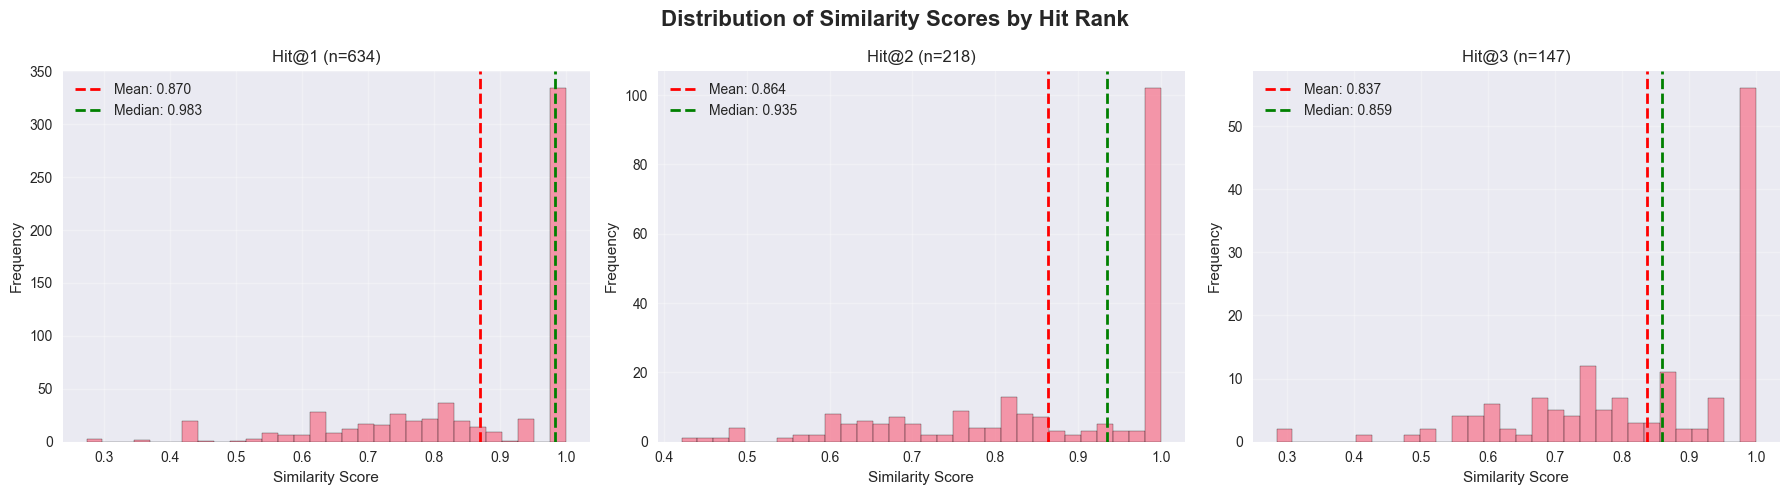

In [25]:
# Visualization 1: Distribution histograms for Hit@1, 2, 3
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribution of Similarity Scores by Hit Rank', fontsize=16, fontweight='bold')

for i, rank in enumerate([1, 2, 3]):
    ax = axes[i]
    rank_data = hit_df[hit_df['rank'] == rank]['gold_analogy_similarity']
    
    if len(rank_data) > 0:
        ax.hist(rank_data, bins=30, alpha=0.7, edgecolor='black')
        ax.axvline(rank_data.mean(), color='red', linestyle='--', linewidth=2, 
                  label=f'Mean: {rank_data.mean():.3f}')
        ax.axvline(rank_data.median(), color='green', linestyle='--', linewidth=2, 
                  label=f'Median: {rank_data.median():.3f}')
        ax.set_xlabel('Similarity Score')
        ax.set_ylabel('Frequency')
        ax.set_title(f'Hit@{rank} (n={len(rank_data)})')
        ax.legend()
        ax.grid(alpha=0.3)
    else:
        ax.text(0.5, 0.5, f'No data for Hit@{rank}', ha='center', va='center', 
               transform=ax.transAxes)
        ax.set_title(f'Hit@{rank}')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'hit_similarity_distributions.png'), dpi=300, bbox_inches='tight')
print("Saved: hit_similarity_distributions.png")
plt.show()


Saved: hit_similarity_cdf.png


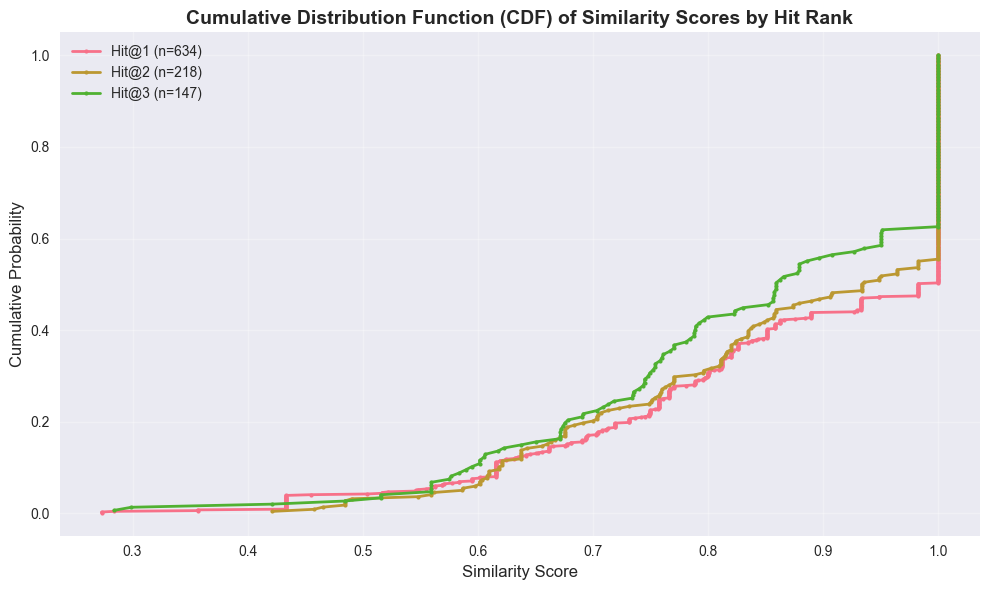

In [26]:
# Visualization 2: Cumulative Distribution Function (CDF)
fig, ax = plt.subplots(figsize=(10, 6))

for rank in [1, 2, 3]:
    rank_data = hit_df[hit_df['rank'] == rank]['gold_analogy_similarity']
    if len(rank_data) > 0:
        sorted_scores = np.sort(rank_data)
        cumulative = np.arange(1, len(sorted_scores) + 1) / len(sorted_scores)
        ax.plot(sorted_scores, cumulative, label=f'Hit@{rank} (n={len(rank_data)})', 
               linewidth=2, marker='o', markersize=3)

ax.set_xlabel('Similarity Score', fontsize=12)
ax.set_ylabel('Cumulative Probability', fontsize=12)
ax.set_title('Cumulative Distribution Function (CDF) of Similarity Scores by Hit Rank', 
            fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'hit_similarity_cdf.png'), dpi=300, bbox_inches='tight')
print("Saved: hit_similarity_cdf.png")
plt.show()


Saved: hit_similarity_boxplot.png


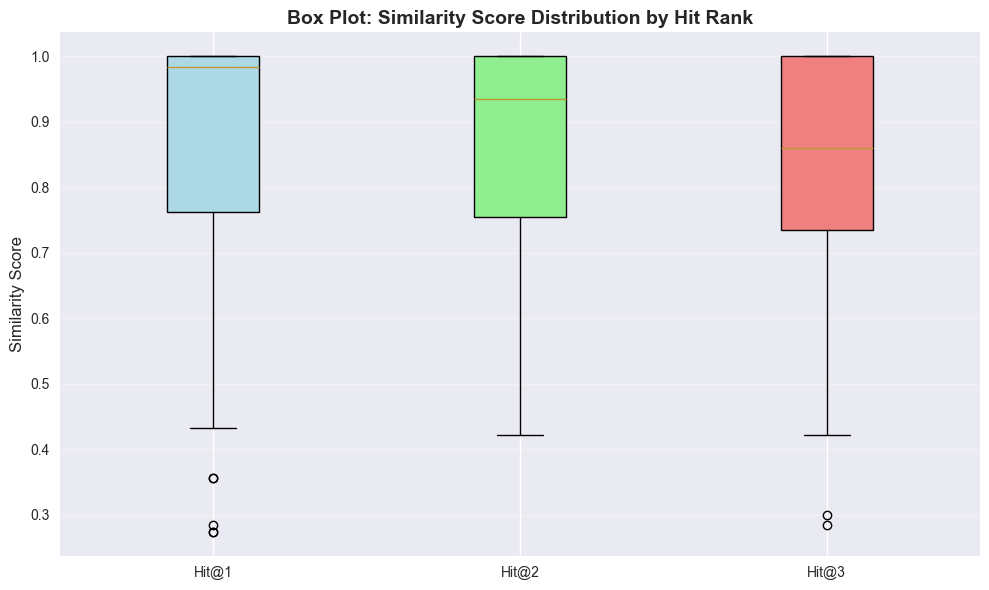

In [27]:
# Visualization 3: Box plots
fig, ax = plt.subplots(figsize=(10, 6))

box_data = [hit_df[hit_df['rank'] == r]['gold_analogy_similarity'].values for r in [1, 2, 3]]
bp = ax.boxplot(box_data, labels=['Hit@1', 'Hit@2', 'Hit@3'], patch_artist=True)

# Color the boxes
colors = ['lightblue', 'lightgreen', 'lightcoral']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.set_ylabel('Similarity Score', fontsize=12)
ax.set_title('Box Plot: Similarity Score Distribution by Hit Rank', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'hit_similarity_boxplot.png'), dpi=300, bbox_inches='tight')
print("Saved: hit_similarity_boxplot.png")
plt.show()


Saved: hit_similarity_violin.png


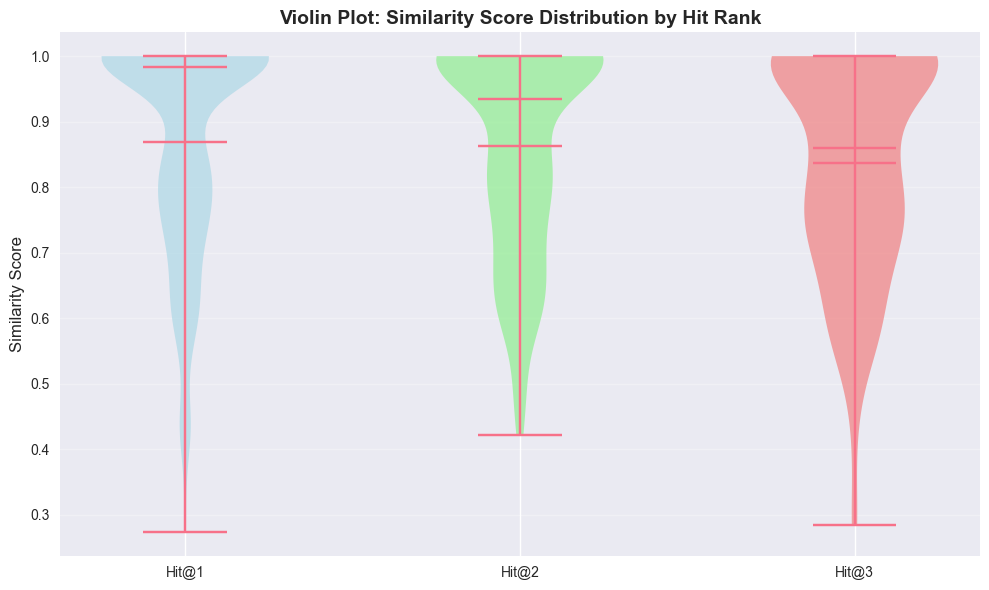

In [28]:
# Visualization 4: Violin plots
fig, ax = plt.subplots(figsize=(10, 6))

violin_data = []
violin_labels = []
for rank in [1, 2, 3]:
    rank_data = hit_df[hit_df['rank'] == rank]['gold_analogy_similarity']
    if len(rank_data) > 0:
        violin_data.append(rank_data.values)
        violin_labels.append(f'Hit@{rank}')

if violin_data:
    parts = ax.violinplot(violin_data, positions=range(len(violin_labels)), 
                         showmeans=True, showmedians=True)
    
    # Color the violins
    for pc, color in zip(parts['bodies'], colors[:len(violin_data)]):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
    
    ax.set_xticks(range(len(violin_labels)))
    ax.set_xticklabels(violin_labels)
    ax.set_ylabel('Similarity Score', fontsize=12)
    ax.set_title('Violin Plot: Similarity Score Distribution by Hit Rank', 
                fontsize=14, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'hit_similarity_violin.png'), dpi=300, bbox_inches='tight')
print("Saved: hit_similarity_violin.png")
plt.show()


Saved: hit_similarity_scatter.png


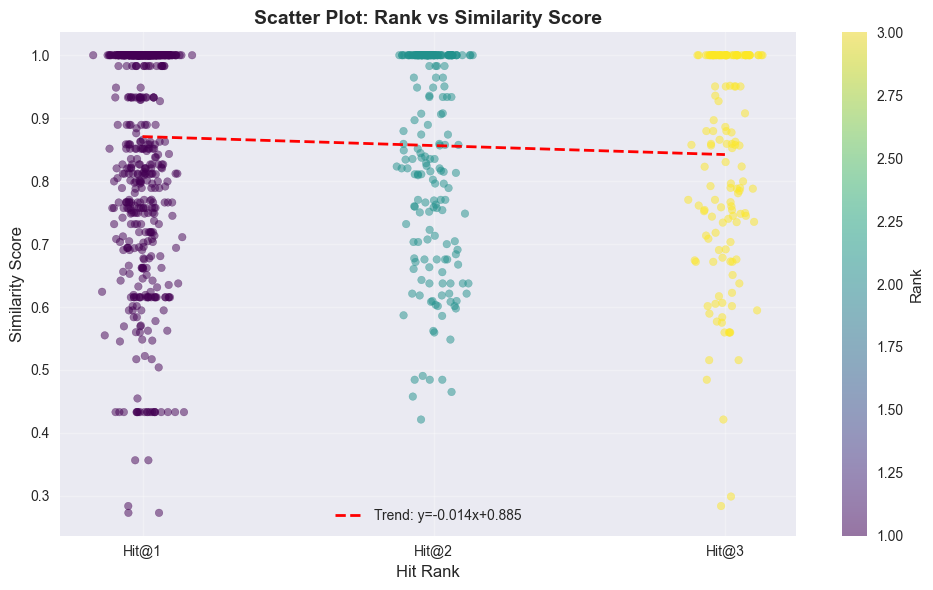

In [29]:
# Visualization 5: Scatter plot (Rank vs Similarity Score)
fig, ax = plt.subplots(figsize=(10, 6))

# Add some jitter to ranks for better visualization
jitter = np.random.normal(0, 0.05, len(hit_df))
scatter_ranks = hit_df['rank'] + jitter

scatter = ax.scatter(scatter_ranks, hit_df['gold_analogy_similarity'], 
                    alpha=0.5, s=30, c=hit_df['rank'], cmap='viridis')

# Add trend line
z = np.polyfit(hit_df['rank'], hit_df['gold_analogy_similarity'], 1)
p = np.poly1d(z)
ax.plot([1, 2, 3], p([1, 2, 3]), "r--", linewidth=2, label=f'Trend: y={z[0]:.3f}x+{z[1]:.3f}')

ax.set_xlabel('Hit Rank', fontsize=12)
ax.set_ylabel('Similarity Score', fontsize=12)
ax.set_title('Scatter Plot: Rank vs Similarity Score', fontsize=14, fontweight='bold')
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Hit@1', 'Hit@2', 'Hit@3'])
ax.legend()
ax.grid(alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Rank')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'hit_similarity_scatter.png'), dpi=300, bbox_inches='tight')
print("Saved: hit_similarity_scatter.png")
plt.show()


In [30]:
def compute_target_analogy_similarity(target, analogy, embedder):
    """
    Compute target-to-analogy similarity using all-MiniLM-L6-v2.
    
    Args:
        target: Target concept name
        analogy: Analogy concept name
        embedder: SentenceTransformer model
        
    Returns:
        Cosine similarity score (float)
    """
    if not target or not analogy:
        return 0.0
    
    try:
        # Encode target and analogy
        target_emb = embedder.encode([target.lower().strip()])[0]
        analogy_emb = embedder.encode([analogy.lower().strip()])[0]
        
        # Compute cosine similarity
        similarity = np.dot(target_emb, analogy_emb) / (
            np.linalg.norm(target_emb) * np.linalg.norm(analogy_emb) + 1e-8
        )
        return float(similarity)
    except Exception as e:
        print(f"Error computing similarity for '{target}' vs '{analogy}': {e}")
        return 0.0

# Compute target-to-analogy similarity for top1_embedding and top1_baseline
print("Computing target-to-analogy similarity for top-1 selections...")
print("This may take a few minutes...")

target_analogy_similarities = []

for idx, row in df.iterrows():
    target = row.get('target', '')
    model = row.get('model', '')
    mode = row.get('mode', '')
    
    # Top-1 Embedding
    top1_embedding = row.get('top1_embedding', '')
    if pd.notna(top1_embedding) and top1_embedding:
        target_emb_sim = compute_target_analogy_similarity(target, top1_embedding, embedder)
        target_analogy_similarities.append({
            'selection_method': 'embedding',
            'analogy': top1_embedding,
            'target_analogy_similarity': target_emb_sim,
            'target': target,
            'model': model,
            'mode': mode,
            'idx': idx
        })
    
    # Top-1 Baseline
    top1_baseline = row.get('top1_baseline', '')
    if pd.notna(top1_baseline) and top1_baseline:
        target_base_sim = compute_target_analogy_similarity(target, top1_baseline, embedder)
        target_analogy_similarities.append({
            'selection_method': 'baseline',
            'analogy': top1_baseline,
            'target_analogy_similarity': target_base_sim,
            'target': target,
            'model': model,
            'mode': mode,
            'idx': idx
        })
    
    if (idx + 1) % 100 == 0:
        print(f"  Processed {idx + 1}/{len(df)} records...")

target_analogy_df = pd.DataFrame(target_analogy_similarities)
print(f"\nComputed {len(target_analogy_df)} target-to-analogy similarities")
print(f"\nBreakdown by method:")
print(target_analogy_df['selection_method'].value_counts())


Computing target-to-analogy similarity for top-1 selections...
This may take a few minutes...
  Processed 100/7704 records...
  Processed 200/7704 records...
  Processed 300/7704 records...
  Processed 400/7704 records...
  Processed 500/7704 records...
  Processed 600/7704 records...
  Processed 700/7704 records...
  Processed 800/7704 records...
  Processed 900/7704 records...
  Processed 1000/7704 records...
  Processed 1100/7704 records...
  Processed 1200/7704 records...
  Processed 1300/7704 records...
  Processed 1400/7704 records...
  Processed 1500/7704 records...
  Processed 1600/7704 records...
  Processed 1700/7704 records...
  Processed 1800/7704 records...
  Processed 1900/7704 records...
  Processed 2000/7704 records...
  Processed 2100/7704 records...
  Processed 2200/7704 records...
  Processed 2300/7704 records...
  Processed 2400/7704 records...
  Processed 2500/7704 records...
  Processed 2600/7704 records...
  Processed 2700/7704 records...
  Processed 2800/7704 re

In [31]:
def extract_gold_analogy_similarity_for_analogy(df, analogy_name_col, selection_method):
    """
    Extract gold-to-analogy similarity for top-1 selections that matched gold sources.
    Only includes analogies that are in gold_ranks (actually matched).
    
    Args:
        df: Main dataframe
        analogy_name_col: Column name for the analogy ('top1_embedding' or 'top1_baseline')
        selection_method: 'embedding' or 'baseline'
        
    Returns:
        DataFrame with gold_analogy_similarity for matched analogies
    """
    results = []
    
    for idx, row in df.iterrows():
        analogy_name = row.get(analogy_name_col, '')
        if pd.isna(analogy_name) or not analogy_name:
            continue
        
        # Check if this analogy is in gold_ranks (actually matched)
        gold_ranks = {}
        if pd.notna(row.get('gold_ranks')):
            try:
                gold_ranks = json.loads(row['gold_ranks'])
            except (json.JSONDecodeError, ValueError, TypeError):
                gold_ranks = {}
        
        # Only process if this analogy matched
        if analogy_name not in gold_ranks:
            continue
        
        # Parse similarity_per_gold
        similarity_per_gold = {}
        if pd.notna(row.get('similarity_per_gold')):
            try:
                similarity_per_gold = json.loads(row['similarity_per_gold'])
            except (json.JSONDecodeError, ValueError, TypeError):
                similarity_per_gold = {}
        
        # Find maximum similarity across all gold sources for this analogy
        max_similarity = 0.0
        for gold_source, gold_data in similarity_per_gold.items():
            if isinstance(gold_data, dict) and 'scores' in gold_data:
                scores_dict = gold_data['scores']
                if isinstance(scores_dict, dict) and analogy_name in scores_dict:
                    similarity = float(scores_dict[analogy_name])
                    max_similarity = max(max_similarity, similarity)
        
        if max_similarity > 0:
            results.append({
                'selection_method': selection_method,
                'analogy': analogy_name,
                'gold_analogy_similarity': max_similarity,
                'target': row.get('target', ''),
                'model': row.get('model', ''),
                'mode': row.get('mode', ''),
                'idx': idx
            })
    
    return pd.DataFrame(results)

# Extract gold-to-analogy similarity for top1_embedding
print("Extracting gold-to-analogy similarity for top1_embedding (matched only)...")
gold_embedding_df = extract_gold_analogy_similarity_for_analogy(df, 'top1_embedding', 'embedding')
print(f"Found {len(gold_embedding_df)} matched top1_embedding analogies")

# Extract gold-to-analogy similarity for top1_baseline
print("\nExtracting gold-to-analogy similarity for top1_baseline (matched only)...")
gold_baseline_df = extract_gold_analogy_similarity_for_analogy(df, 'top1_baseline', 'baseline')
print(f"Found {len(gold_baseline_df)} matched top1_baseline analogies")

# Combine
gold_analogy_df = pd.concat([gold_embedding_df, gold_baseline_df], ignore_index=True)
print(f"\nTotal matched analogies: {len(gold_analogy_df)}")


Extracting gold-to-analogy similarity for top1_embedding (matched only)...
Found 220 matched top1_embedding analogies

Extracting gold-to-analogy similarity for top1_baseline (matched only)...
Found 634 matched top1_baseline analogies

Total matched analogies: 854


In [32]:
# Prepare data for top1_embedding vs LLM judge comparison
print("Preparing data for top1_embedding vs LLM judge comparison...")

# Merge target-to-analogy and gold-to-analogy similarities
embedding_comparison_data = []

for idx, row in df.iterrows():
    # Get top1_embedding
    top1_embedding = row.get('top1_embedding', '')
    if pd.isna(top1_embedding) or not top1_embedding:
        continue
    
    # Get target-to-analogy similarity
    target_sim_row = target_analogy_df[
        (target_analogy_df['idx'] == idx) & 
        (target_analogy_df['selection_method'] == 'embedding')
    ]
    target_analogy_sim = target_sim_row['target_analogy_similarity'].values[0] if len(target_sim_row) > 0 else None
    
    # Get gold-to-analogy similarity (only if matched)
    gold_sim_row = gold_analogy_df[
        (gold_analogy_df['idx'] == idx) & 
        (gold_analogy_df['selection_method'] == 'embedding')
    ]
    gold_analogy_sim = gold_sim_row['gold_analogy_similarity'].values[0] if len(gold_sim_row) > 0 else None
    
    # Get LLM judge scores
    judge_embedding = {}
    if pd.notna(row.get('judge_embedding')):
        try:
            judge_embedding = json.loads(row['judge_embedding'])
        except (json.JSONDecodeError, ValueError, TypeError):
            judge_embedding = {}
    
    if judge_embedding and isinstance(judge_embedding, dict):
        embedding_comparison_data.append({
            'target': row.get('target', ''),
            'analogy': top1_embedding,
            'target_analogy_similarity': target_analogy_sim,
            'gold_analogy_similarity': gold_analogy_sim,
            'judge_coherence': judge_embedding.get('coherence', None),
            'judge_mapping': judge_embedding.get('mapping', None),
            'judge_explanatory': judge_embedding.get('explanatory', None),
            'judge_average': judge_embedding.get('average', None),
            'model': row.get('model', ''),
            'mode': row.get('mode', '')
        })

embedding_comparison_df = pd.DataFrame(embedding_comparison_data)
print(f"Prepared {len(embedding_comparison_df)} records for embedding comparison")

# Filter out None values for analysis
embedding_comparison_clean = embedding_comparison_df.dropna(subset=['target_analogy_similarity', 'judge_average'])
print(f"Records with both similarity and judge scores: {len(embedding_comparison_clean)}")


Preparing data for top1_embedding vs LLM judge comparison...


Prepared 7697 records for embedding comparison
Records with both similarity and judge scores: 7697


Saved: top1_embedding_target_vs_judge.png


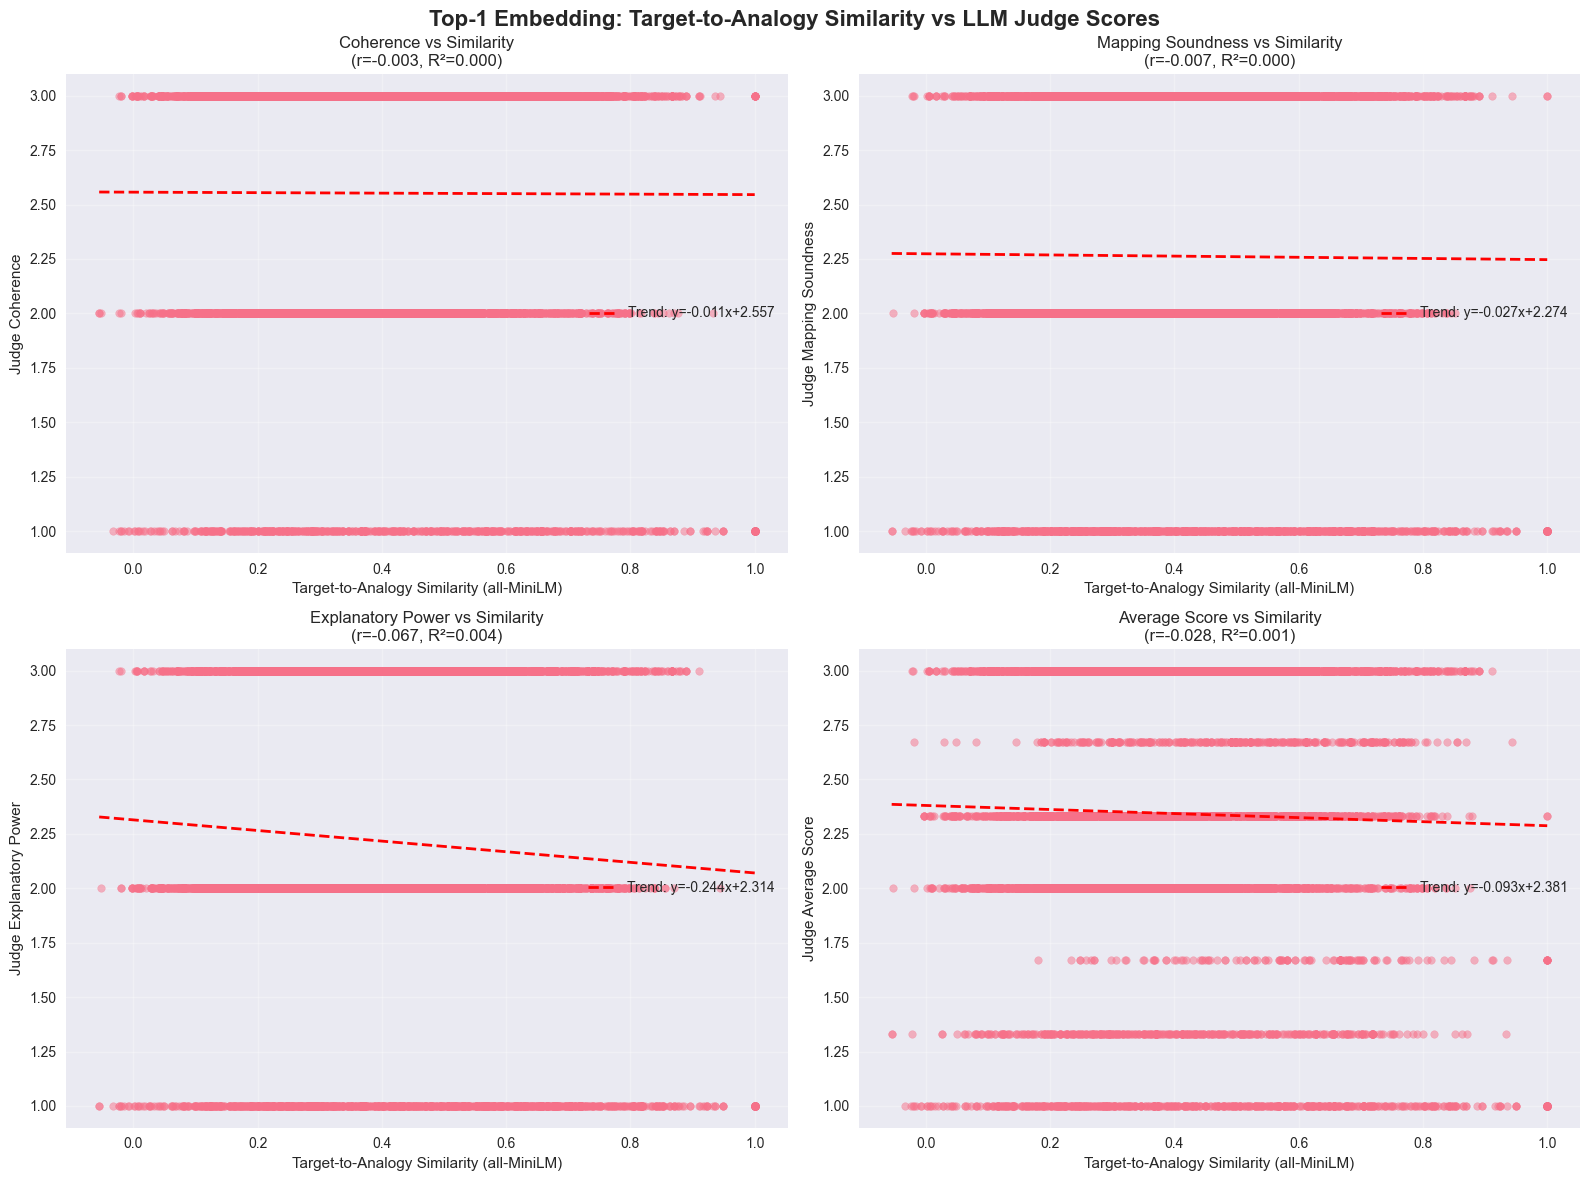

In [33]:
# Visualization: Top-1 Embedding - Target-to-Analogy Similarity vs LLM Judge
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Top-1 Embedding: Target-to-Analogy Similarity vs LLM Judge Scores', 
            fontsize=16, fontweight='bold')

judge_metrics = ['judge_coherence', 'judge_mapping', 'judge_explanatory', 'judge_average']
titles = ['Coherence', 'Mapping Soundness', 'Explanatory Power', 'Average Score']

for i, (metric, title) in enumerate(zip(judge_metrics, titles)):
    ax = axes[i // 2, i % 2]
    
    # Filter valid data
    plot_data = embedding_comparison_clean.dropna(subset=['target_analogy_similarity', metric])
    
    if len(plot_data) > 0:
        # Scatter plot
        ax.scatter(plot_data['target_analogy_similarity'], plot_data[metric], 
                  alpha=0.5, s=30)
        
        # Regression line
        z = np.polyfit(plot_data['target_analogy_similarity'], plot_data[metric], 1)
        p = np.poly1d(z)
        x_line = np.linspace(plot_data['target_analogy_similarity'].min(), 
                            plot_data['target_analogy_similarity'].max(), 100)
        ax.plot(x_line, p(x_line), "r--", linewidth=2, 
               label=f'Trend: y={z[0]:.3f}x+{z[1]:.3f}')
        
        # Calculate correlation
        corr = plot_data['target_analogy_similarity'].corr(plot_data[metric])
        r_squared = corr ** 2
        
        ax.set_xlabel('Target-to-Analogy Similarity (all-MiniLM)', fontsize=11)
        ax.set_ylabel(f'Judge {title}', fontsize=11)
        ax.set_title(f'{title} vs Similarity\n(r={corr:.3f}, R²={r_squared:.3f})', fontsize=12)
        ax.legend()
        ax.grid(alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'top1_embedding_target_vs_judge.png'), 
           dpi=300, bbox_inches='tight')
print("Saved: top1_embedding_target_vs_judge.png")
plt.show()


Saved: top1_embedding_gold_vs_judge.png


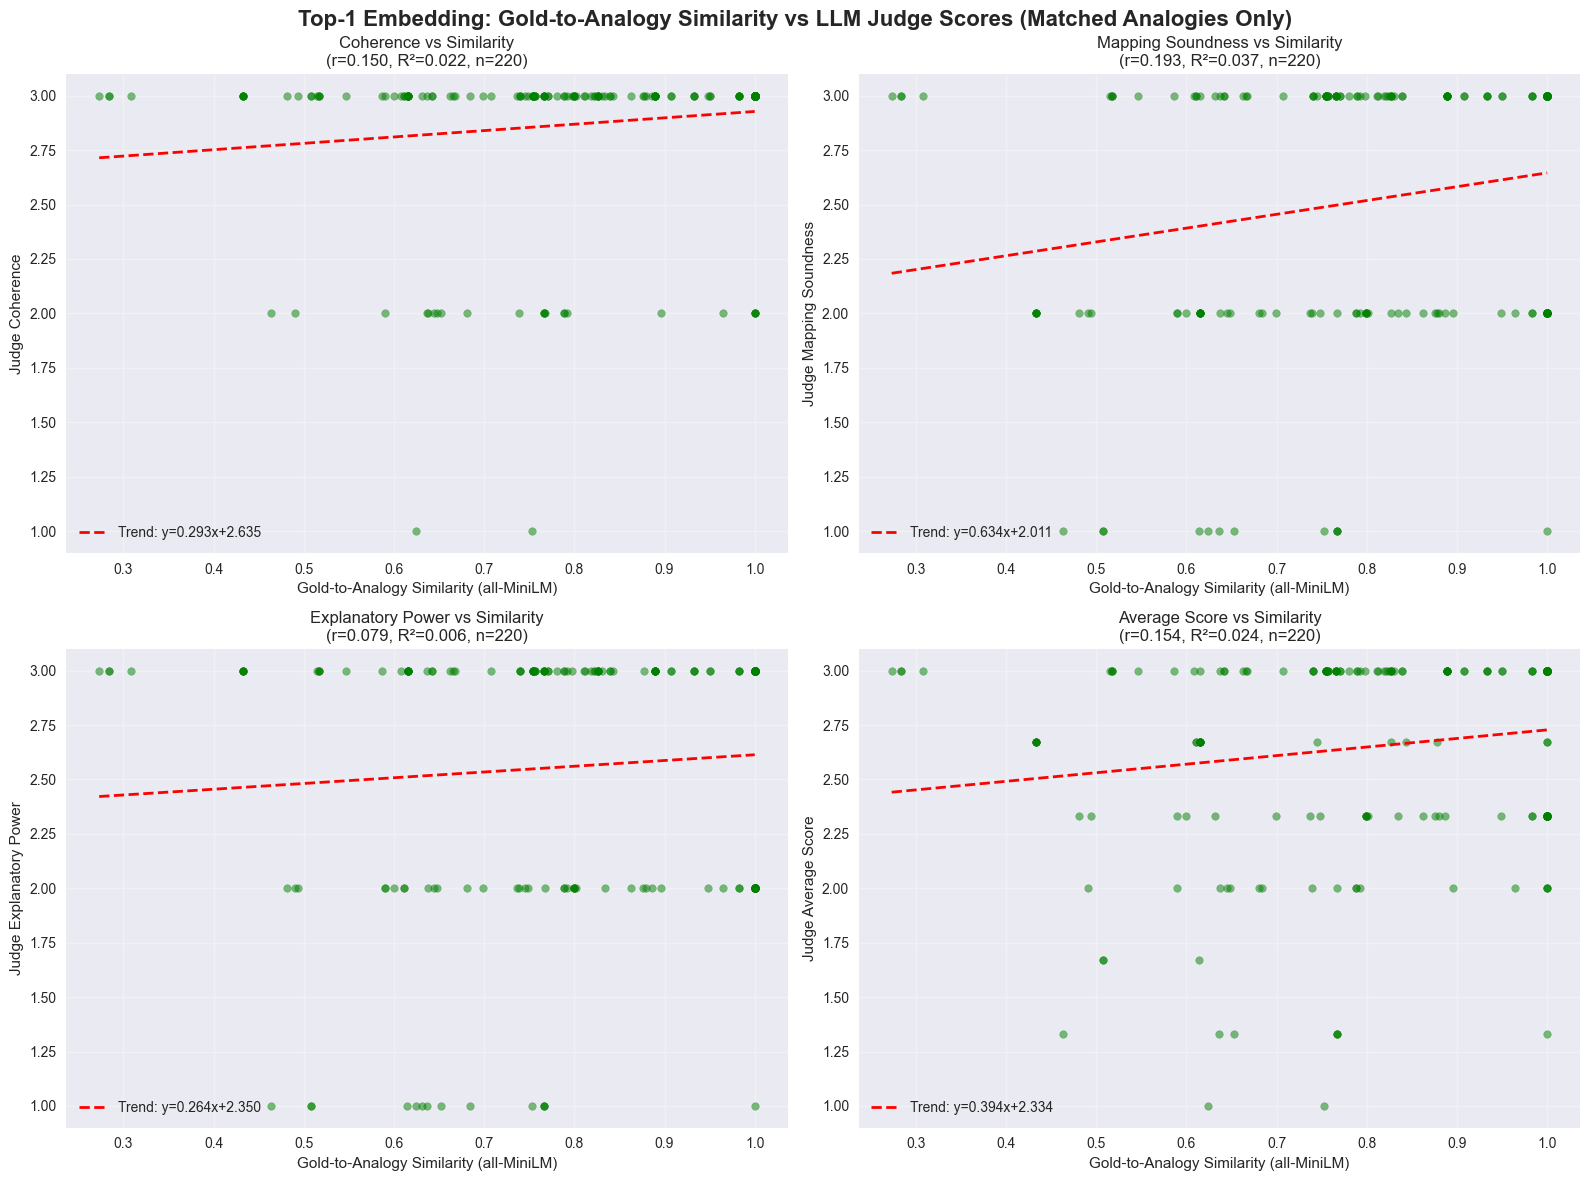

In [34]:
# Visualization: Top-1 Embedding - Gold-to-Analogy Similarity vs LLM Judge (matched only)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Top-1 Embedding: Gold-to-Analogy Similarity vs LLM Judge Scores (Matched Analogies Only)', 
            fontsize=16, fontweight='bold')

# Filter to only matched analogies (have gold_analogy_similarity)
embedding_gold_comparison = embedding_comparison_df.dropna(subset=['gold_analogy_similarity', 'judge_average'])

for i, (metric, title) in enumerate(zip(judge_metrics, titles)):
    ax = axes[i // 2, i % 2]
    
    # Filter valid data
    plot_data = embedding_gold_comparison.dropna(subset=['gold_analogy_similarity', metric])
    
    if len(plot_data) > 0:
        # Scatter plot
        ax.scatter(plot_data['gold_analogy_similarity'], plot_data[metric], 
                  alpha=0.5, s=30, color='green')
        
        # Regression line
        z = np.polyfit(plot_data['gold_analogy_similarity'], plot_data[metric], 1)
        p = np.poly1d(z)
        x_line = np.linspace(plot_data['gold_analogy_similarity'].min(), 
                            plot_data['gold_analogy_similarity'].max(), 100)
        ax.plot(x_line, p(x_line), "r--", linewidth=2, 
               label=f'Trend: y={z[0]:.3f}x+{z[1]:.3f}')
        
        # Calculate correlation
        corr = plot_data['gold_analogy_similarity'].corr(plot_data[metric])
        r_squared = corr ** 2
        
        ax.set_xlabel('Gold-to-Analogy Similarity (all-MiniLM)', fontsize=11)
        ax.set_ylabel(f'Judge {title}', fontsize=11)
        ax.set_title(f'{title} vs Similarity\n(r={corr:.3f}, R²={r_squared:.3f}, n={len(plot_data)})', 
                    fontsize=12)
        ax.legend()
        ax.grid(alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'top1_embedding_gold_vs_judge.png'), 
           dpi=300, bbox_inches='tight')
print("Saved: top1_embedding_gold_vs_judge.png")
plt.show()


Saved: top1_embedding_correlation_heatmap.png


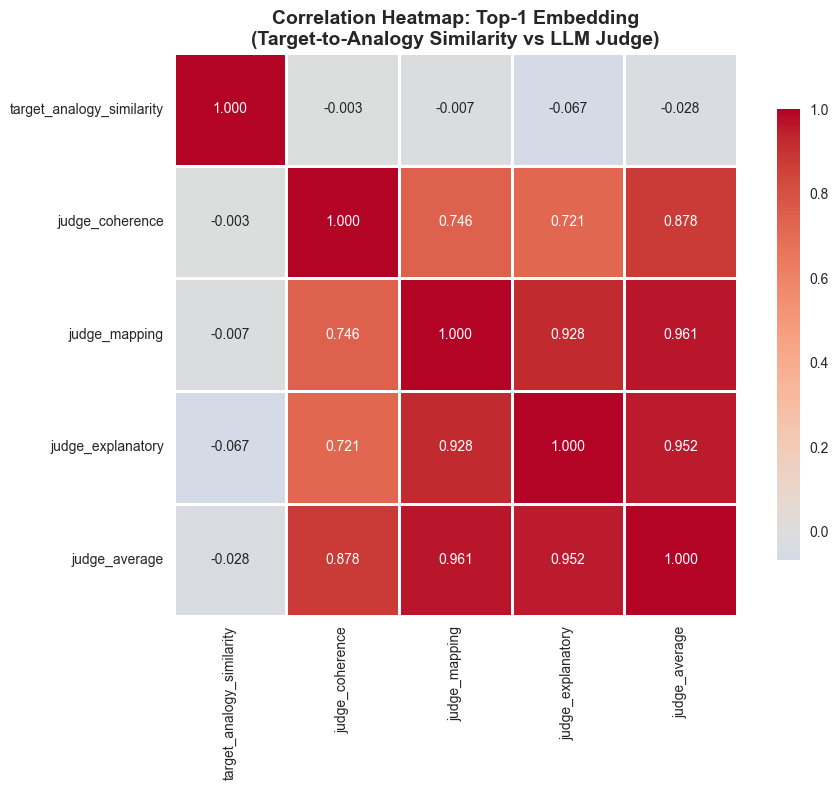

In [35]:
# Correlation heatmap for top1_embedding
embedding_corr_data = embedding_comparison_clean[[
    'target_analogy_similarity', 'judge_coherence', 'judge_mapping', 
    'judge_explanatory', 'judge_average'
]].dropna()

if len(embedding_corr_data) > 0:
    embedding_corr_matrix = embedding_corr_data.corr()
    
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(embedding_corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
               center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
    ax.set_title('Correlation Heatmap: Top-1 Embedding\n(Target-to-Analogy Similarity vs LLM Judge)', 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'top1_embedding_correlation_heatmap.png'), 
               dpi=300, bbox_inches='tight')
    print("Saved: top1_embedding_correlation_heatmap.png")
    plt.show()
else:
    print("No data for correlation heatmap")


In [36]:
# Prepare data for top1_baseline vs LLM judge comparison
print("Preparing data for top1_baseline vs LLM judge comparison...")

baseline_comparison_data = []

for idx, row in df.iterrows():
    # Get top1_baseline
    top1_baseline = row.get('top1_baseline', '')
    if pd.isna(top1_baseline) or not top1_baseline:
        continue
    
    # Get target-to-analogy similarity
    target_sim_row = target_analogy_df[
        (target_analogy_df['idx'] == idx) & 
        (target_analogy_df['selection_method'] == 'baseline')
    ]
    target_analogy_sim = target_sim_row['target_analogy_similarity'].values[0] if len(target_sim_row) > 0 else None
    
    # Get gold-to-analogy similarity (only if matched)
    gold_sim_row = gold_analogy_df[
        (gold_analogy_df['idx'] == idx) & 
        (gold_analogy_df['selection_method'] == 'baseline')
    ]
    gold_analogy_sim = gold_sim_row['gold_analogy_similarity'].values[0] if len(gold_sim_row) > 0 else None
    
    # Get LLM judge scores
    judge_baseline = {}
    if pd.notna(row.get('judge_baseline')):
        try:
            judge_baseline = json.loads(row['judge_baseline'])
        except (json.JSONDecodeError, ValueError, TypeError):
            judge_baseline = {}
    
    if judge_baseline and isinstance(judge_baseline, dict):
        baseline_comparison_data.append({
            'target': row.get('target', ''),
            'analogy': top1_baseline,
            'target_analogy_similarity': target_analogy_sim,
            'gold_analogy_similarity': gold_analogy_sim,
            'judge_coherence': judge_baseline.get('coherence', None),
            'judge_mapping': judge_baseline.get('mapping', None),
            'judge_explanatory': judge_baseline.get('explanatory', None),
            'judge_average': judge_baseline.get('average', None),
            'model': row.get('model', ''),
            'mode': row.get('mode', '')
        })

baseline_comparison_df = pd.DataFrame(baseline_comparison_data)
print(f"Prepared {len(baseline_comparison_df)} records for baseline comparison")

# Filter out None values for analysis
baseline_comparison_clean = baseline_comparison_df.dropna(subset=['target_analogy_similarity', 'judge_average'])
print(f"Records with both similarity and judge scores: {len(baseline_comparison_clean)}")


Preparing data for top1_baseline vs LLM judge comparison...


Prepared 7697 records for baseline comparison
Records with both similarity and judge scores: 7697


Saved: top1_baseline_target_vs_judge.png


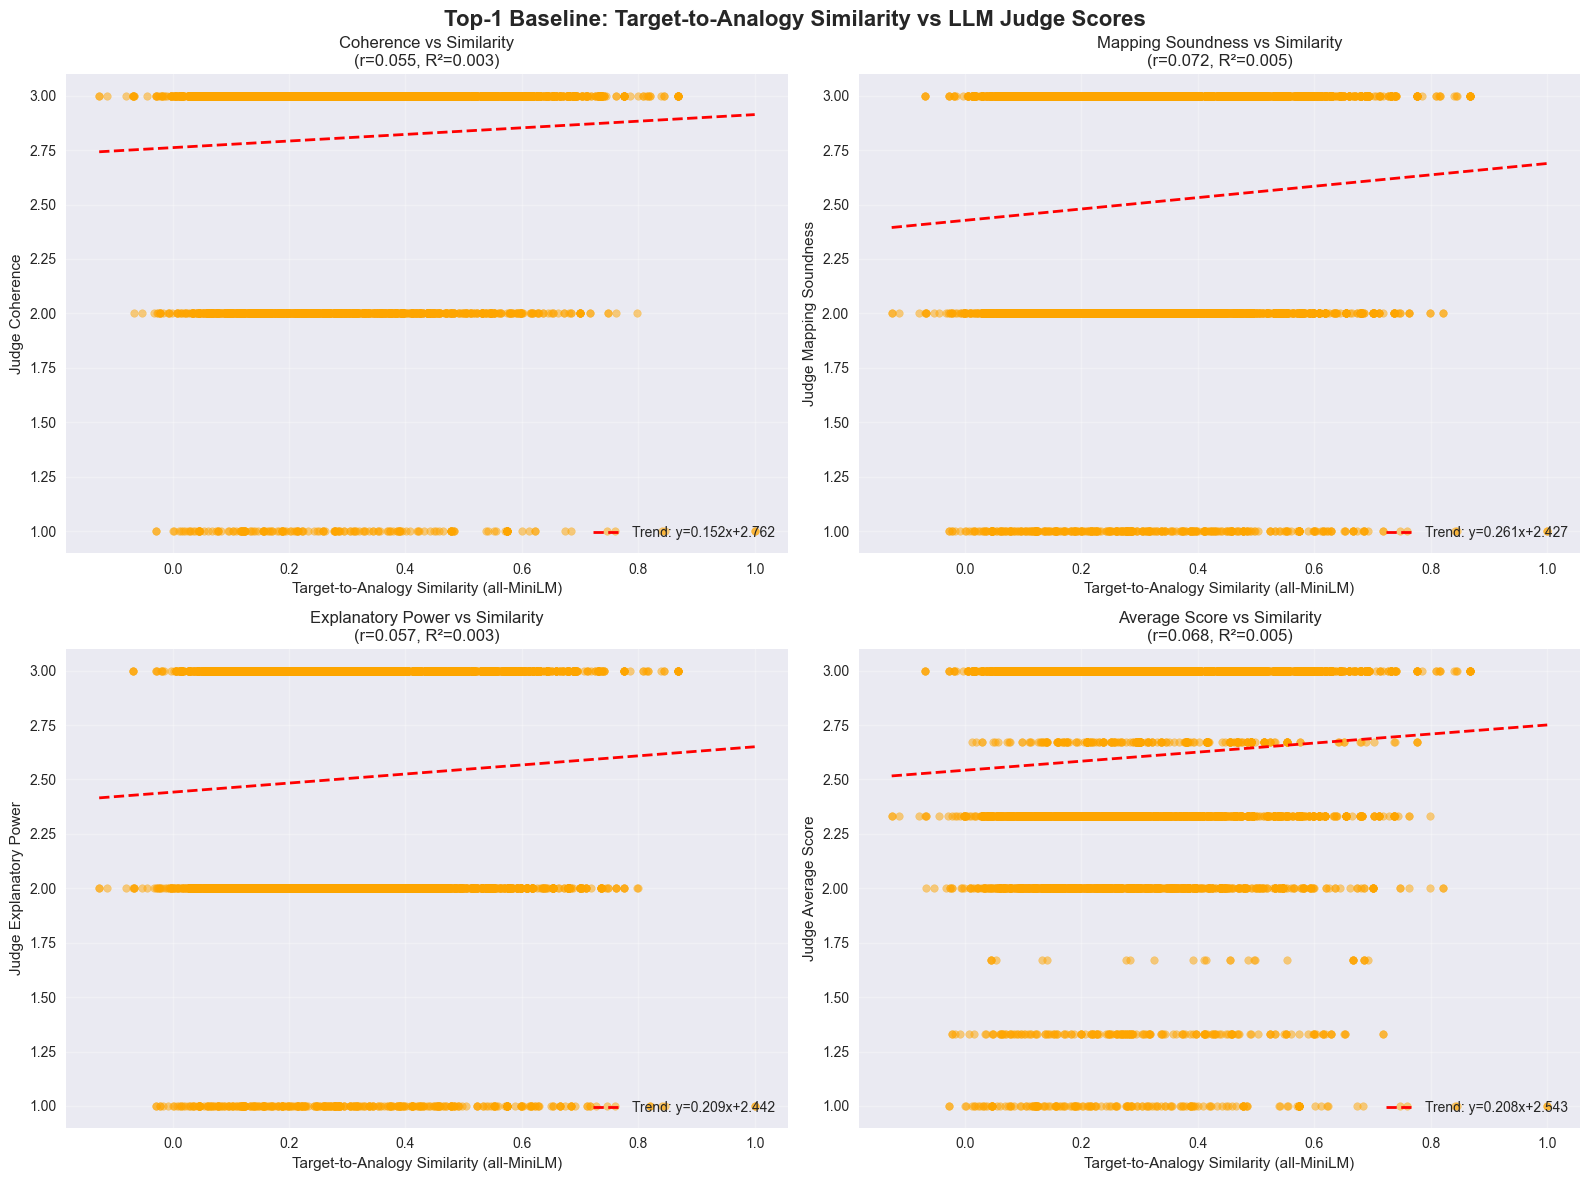

In [37]:
# Visualization: Top-1 Baseline - Target-to-Analogy Similarity vs LLM Judge
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Top-1 Baseline: Target-to-Analogy Similarity vs LLM Judge Scores', 
            fontsize=16, fontweight='bold')

for i, (metric, title) in enumerate(zip(judge_metrics, titles)):
    ax = axes[i // 2, i % 2]
    
    # Filter valid data
    plot_data = baseline_comparison_clean.dropna(subset=['target_analogy_similarity', metric])
    
    if len(plot_data) > 0:
        # Scatter plot
        ax.scatter(plot_data['target_analogy_similarity'], plot_data[metric], 
                  alpha=0.5, s=30, color='orange')
        
        # Regression line
        z = np.polyfit(plot_data['target_analogy_similarity'], plot_data[metric], 1)
        p = np.poly1d(z)
        x_line = np.linspace(plot_data['target_analogy_similarity'].min(), 
                            plot_data['target_analogy_similarity'].max(), 100)
        ax.plot(x_line, p(x_line), "r--", linewidth=2, 
               label=f'Trend: y={z[0]:.3f}x+{z[1]:.3f}')
        
        # Calculate correlation
        corr = plot_data['target_analogy_similarity'].corr(plot_data[metric])
        r_squared = corr ** 2
        
        ax.set_xlabel('Target-to-Analogy Similarity (all-MiniLM)', fontsize=11)
        ax.set_ylabel(f'Judge {title}', fontsize=11)
        ax.set_title(f'{title} vs Similarity\n(r={corr:.3f}, R²={r_squared:.3f})', fontsize=12)
        ax.legend()
        ax.grid(alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'top1_baseline_target_vs_judge.png'), 
           dpi=300, bbox_inches='tight')
print("Saved: top1_baseline_target_vs_judge.png")
plt.show()


Saved: top1_baseline_gold_vs_judge.png


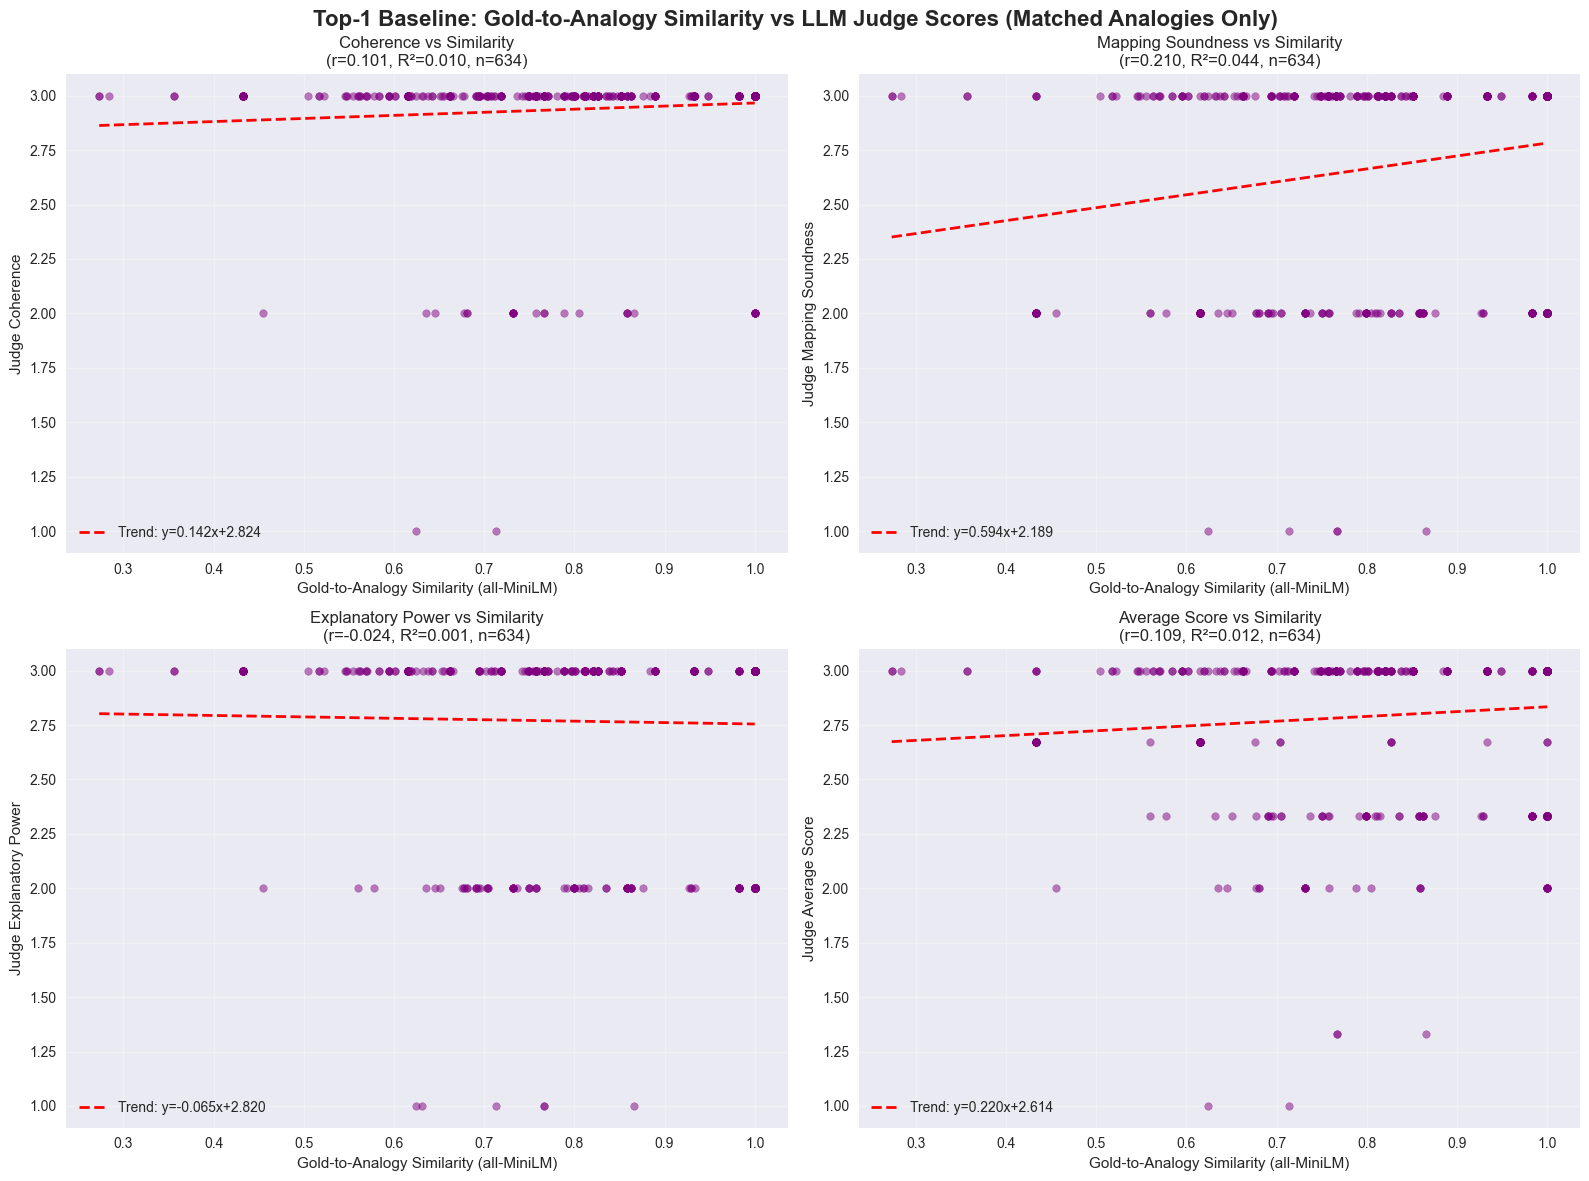

In [38]:
# Visualization: Top-1 Baseline - Gold-to-Analogy Similarity vs LLM Judge (matched only)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Top-1 Baseline: Gold-to-Analogy Similarity vs LLM Judge Scores (Matched Analogies Only)', 
            fontsize=16, fontweight='bold')

# Filter to only matched analogies (have gold_analogy_similarity)
baseline_gold_comparison = baseline_comparison_df.dropna(subset=['gold_analogy_similarity', 'judge_average'])

for i, (metric, title) in enumerate(zip(judge_metrics, titles)):
    ax = axes[i // 2, i % 2]
    
    # Filter valid data
    plot_data = baseline_gold_comparison.dropna(subset=['gold_analogy_similarity', metric])
    
    if len(plot_data) > 0:
        # Scatter plot
        ax.scatter(plot_data['gold_analogy_similarity'], plot_data[metric], 
                  alpha=0.5, s=30, color='purple')
        
        # Regression line
        z = np.polyfit(plot_data['gold_analogy_similarity'], plot_data[metric], 1)
        p = np.poly1d(z)
        x_line = np.linspace(plot_data['gold_analogy_similarity'].min(), 
                            plot_data['gold_analogy_similarity'].max(), 100)
        ax.plot(x_line, p(x_line), "r--", linewidth=2, 
               label=f'Trend: y={z[0]:.3f}x+{z[1]:.3f}')
        
        # Calculate correlation
        corr = plot_data['gold_analogy_similarity'].corr(plot_data[metric])
        r_squared = corr ** 2
        
        ax.set_xlabel('Gold-to-Analogy Similarity (all-MiniLM)', fontsize=11)
        ax.set_ylabel(f'Judge {title}', fontsize=11)
        ax.set_title(f'{title} vs Similarity\n(r={corr:.3f}, R²={r_squared:.3f}, n={len(plot_data)})', 
                    fontsize=12)
        ax.legend()
        ax.grid(alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'top1_baseline_gold_vs_judge.png'), 
           dpi=300, bbox_inches='tight')
print("Saved: top1_baseline_gold_vs_judge.png")
plt.show()


Saved: top1_baseline_correlation_heatmap.png


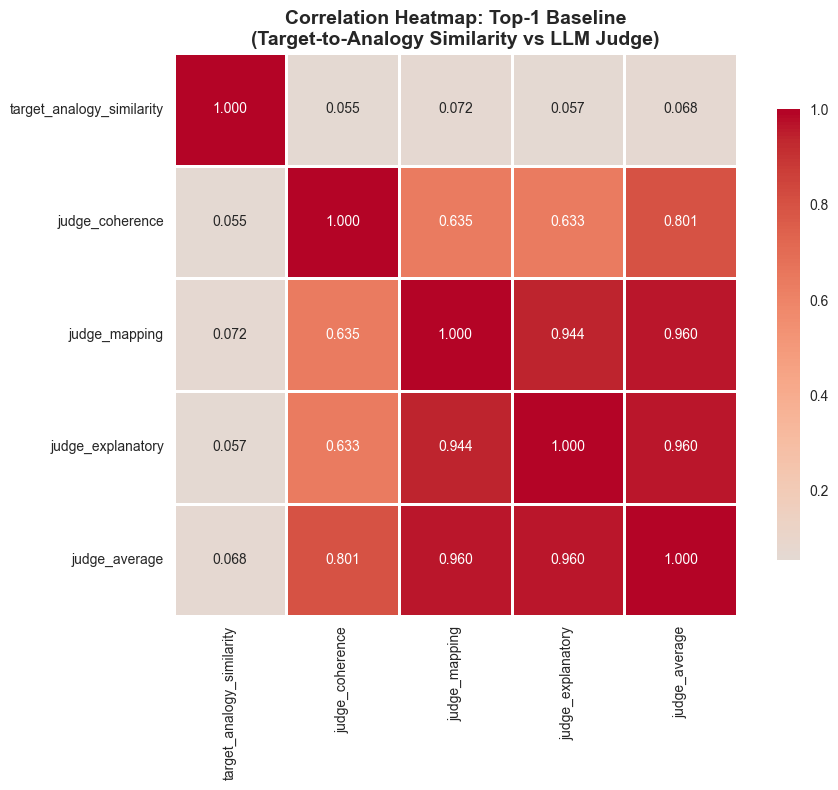

In [39]:
# Correlation heatmap for top1_baseline
baseline_corr_data = baseline_comparison_clean[[
    'target_analogy_similarity', 'judge_coherence', 'judge_mapping', 
    'judge_explanatory', 'judge_average'
]].dropna()

if len(baseline_corr_data) > 0:
    baseline_corr_matrix = baseline_corr_data.corr()
    
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(baseline_corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
               center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
    ax.set_title('Correlation Heatmap: Top-1 Baseline\n(Target-to-Analogy Similarity vs LLM Judge)', 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'top1_baseline_correlation_heatmap.png'), 
               dpi=300, bbox_inches='tight')
    print("Saved: top1_baseline_correlation_heatmap.png")
    plt.show()
else:
    print("No data for correlation heatmap")


Saved: embedding_vs_baseline_comparison.png


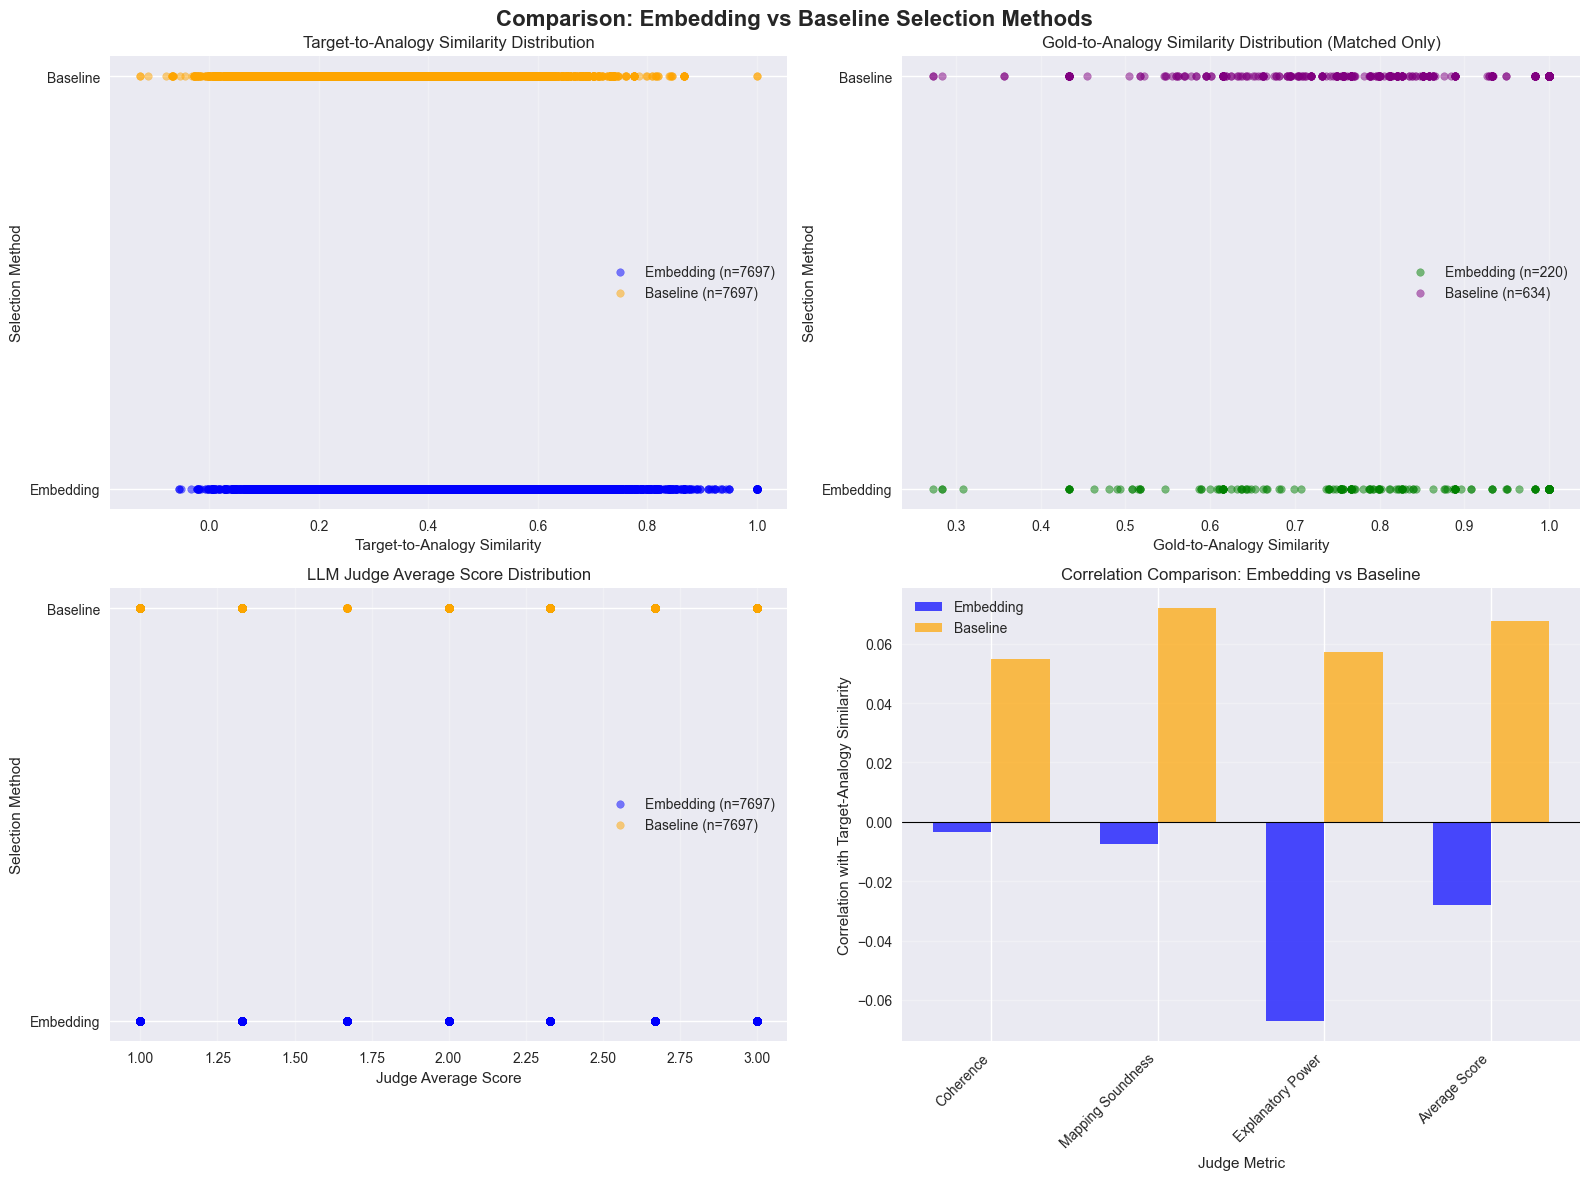

In [40]:
# Combined Comparison: Embedding vs Baseline
# Side-by-side scatter plots for target-to-analogy similarity
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Comparison: Embedding vs Baseline Selection Methods', 
            fontsize=16, fontweight='bold')

# Target-to-Analogy Similarity comparison
ax1 = axes[0, 0]
embedding_target = embedding_comparison_clean['target_analogy_similarity'].dropna()
baseline_target = baseline_comparison_clean['target_analogy_similarity'].dropna()

if len(embedding_target) > 0 and len(baseline_target) > 0:
    ax1.scatter(embedding_target, [1]*len(embedding_target), alpha=0.5, s=30, 
              label=f'Embedding (n={len(embedding_target)})', color='blue')
    ax1.scatter(baseline_target, [2]*len(baseline_target), alpha=0.5, s=30, 
              label=f'Baseline (n={len(baseline_target)})', color='orange')
    ax1.set_xlabel('Target-to-Analogy Similarity', fontsize=11)
    ax1.set_ylabel('Selection Method', fontsize=11)
    ax1.set_yticks([1, 2])
    ax1.set_yticklabels(['Embedding', 'Baseline'])
    ax1.set_title('Target-to-Analogy Similarity Distribution', fontsize=12)
    ax1.legend()
    ax1.grid(alpha=0.3, axis='x')

# Gold-to-Analogy Similarity comparison (matched only)
ax2 = axes[0, 1]
embedding_gold = embedding_gold_comparison['gold_analogy_similarity'].dropna()
baseline_gold = baseline_gold_comparison['gold_analogy_similarity'].dropna()

if len(embedding_gold) > 0 and len(baseline_gold) > 0:
    ax2.scatter(embedding_gold, [1]*len(embedding_gold), alpha=0.5, s=30, 
              label=f'Embedding (n={len(embedding_gold)})', color='green')
    ax2.scatter(baseline_gold, [2]*len(baseline_gold), alpha=0.5, s=30, 
              label=f'Baseline (n={len(baseline_gold)})', color='purple')
    ax2.set_xlabel('Gold-to-Analogy Similarity', fontsize=11)
    ax2.set_ylabel('Selection Method', fontsize=11)
    ax2.set_yticks([1, 2])
    ax2.set_yticklabels(['Embedding', 'Baseline'])
    ax2.set_title('Gold-to-Analogy Similarity Distribution (Matched Only)', fontsize=12)
    ax2.legend()
    ax2.grid(alpha=0.3, axis='x')

# Judge Average Score comparison
ax3 = axes[1, 0]
embedding_judge = embedding_comparison_clean['judge_average'].dropna()
baseline_judge = baseline_comparison_clean['judge_average'].dropna()

if len(embedding_judge) > 0 and len(baseline_judge) > 0:
    ax3.scatter(embedding_judge, [1]*len(embedding_judge), alpha=0.5, s=30, 
              label=f'Embedding (n={len(embedding_judge)})', color='blue')
    ax3.scatter(baseline_judge, [2]*len(baseline_judge), alpha=0.5, s=30, 
              label=f'Baseline (n={len(baseline_judge)})', color='orange')
    ax3.set_xlabel('Judge Average Score', fontsize=11)
    ax3.set_ylabel('Selection Method', fontsize=11)
    ax3.set_yticks([1, 2])
    ax3.set_yticklabels(['Embedding', 'Baseline'])
    ax3.set_title('LLM Judge Average Score Distribution', fontsize=12)
    ax3.legend()
    ax3.grid(alpha=0.3, axis='x')

# Correlation comparison bar chart
ax4 = axes[1, 1]

# Calculate correlations for embedding
embedding_corrs = {}
if len(embedding_comparison_clean) > 0:
    for metric in judge_metrics:
        plot_data = embedding_comparison_clean.dropna(subset=['target_analogy_similarity', metric])
        if len(plot_data) > 0:
            embedding_corrs[metric] = plot_data['target_analogy_similarity'].corr(plot_data[metric])

# Calculate correlations for baseline
baseline_corrs = {}
if len(baseline_comparison_clean) > 0:
    for metric in judge_metrics:
        plot_data = baseline_comparison_clean.dropna(subset=['target_analogy_similarity', metric])
        if len(plot_data) > 0:
            baseline_corrs[metric] = plot_data['target_analogy_similarity'].corr(plot_data[metric])

# Create bar chart
if embedding_corrs and baseline_corrs:
    x = np.arange(len(titles))
    width = 0.35
    
    embedding_vals = [embedding_corrs.get(m, 0) for m in judge_metrics]
    baseline_vals = [baseline_corrs.get(m, 0) for m in judge_metrics]
    
    ax4.bar(x - width/2, embedding_vals, width, label='Embedding', color='blue', alpha=0.7)
    ax4.bar(x + width/2, baseline_vals, width, label='Baseline', color='orange', alpha=0.7)
    
    ax4.set_xlabel('Judge Metric', fontsize=11)
    ax4.set_ylabel('Correlation with Target-Analogy Similarity', fontsize=11)
    ax4.set_title('Correlation Comparison: Embedding vs Baseline', fontsize=12)
    ax4.set_xticks(x)
    ax4.set_xticklabels(titles, rotation=45, ha='right')
    ax4.legend()
    ax4.grid(alpha=0.3, axis='y')
    ax4.axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'embedding_vs_baseline_comparison.png'), 
           dpi=300, bbox_inches='tight')
print("Saved: embedding_vs_baseline_comparison.png")
plt.show()


In [41]:
# Summary Statistics and Insights
print("=" * 70)
print("SUMMARY STATISTICS AND INSIGHTS")
print("=" * 70)

# Hit@1,2,3 similarity statistics
print("\n1. Hit@1,2,3 Similarity Score Statistics:")
print("-" * 70)
for rank in [1, 2, 3]:
    rank_data = hit_df[hit_df['rank'] == rank]['gold_analogy_similarity']
    if len(rank_data) > 0:
        print(f"Hit@{rank}:")
        print(f"  Count: {len(rank_data)}")
        print(f"  Mean: {rank_data.mean():.4f}")
        print(f"  Median: {rank_data.median():.4f}")
        print(f"  Std: {rank_data.std():.4f}")
        print(f"  Min: {rank_data.min():.4f}")
        print(f"  Max: {rank_data.max():.4f}")
        print()

# Correlation coefficients for embedding
print("\n2. Top-1 Embedding: Correlation with LLM Judge Scores")
print("-" * 70)
if len(embedding_comparison_clean) > 0:
    for metric, title in zip(judge_metrics, titles):
        plot_data = embedding_comparison_clean.dropna(subset=['target_analogy_similarity', metric])
        if len(plot_data) > 0:
            corr = plot_data['target_analogy_similarity'].corr(plot_data[metric])
            print(f"  {title}: r = {corr:.4f} (n={len(plot_data)})")

# Correlation coefficients for baseline
print("\n3. Top-1 Baseline: Correlation with LLM Judge Scores")
print("-" * 70)
if len(baseline_comparison_clean) > 0:
    for metric, title in zip(judge_metrics, titles):
        plot_data = baseline_comparison_clean.dropna(subset=['target_analogy_similarity', metric])
        if len(plot_data) > 0:
            corr = plot_data['target_analogy_similarity'].corr(plot_data[metric])
            print(f"  {title}: r = {corr:.4f} (n={len(plot_data)})")

# Comparison statistics
print("\n4. Embedding vs Baseline Comparison:")
print("-" * 70)
if len(embedding_comparison_clean) > 0 and len(baseline_comparison_clean) > 0:
    print(f"  Target-Analogy Similarity:")
    print(f"    Embedding: mean={embedding_comparison_clean['target_analogy_similarity'].mean():.4f}, "
          f"median={embedding_comparison_clean['target_analogy_similarity'].median():.4f}")
    print(f"    Baseline: mean={baseline_comparison_clean['target_analogy_similarity'].mean():.4f}, "
          f"median={baseline_comparison_clean['target_analogy_similarity'].median():.4f}")
    
    print(f"\n  Judge Average Score:")
    print(f"    Embedding: mean={embedding_comparison_clean['judge_average'].mean():.4f}, "
          f"median={embedding_comparison_clean['judge_average'].median():.4f}")
    print(f"    Baseline: mean={baseline_comparison_clean['judge_average'].mean():.4f}, "
          f"median={baseline_comparison_clean['judge_average'].median():.4f}")

# Gold-to-analogy similarity (matched only)
print("\n5. Gold-to-Analogy Similarity (Matched Analogies Only):")
print("-" * 70)
if len(embedding_gold_comparison) > 0:
    print(f"  Embedding: mean={embedding_gold_comparison['gold_analogy_similarity'].mean():.4f}, "
          f"n={len(embedding_gold_comparison)}")
if len(baseline_gold_comparison) > 0:
    print(f"  Baseline: mean={baseline_gold_comparison['gold_analogy_similarity'].mean():.4f}, "
          f"n={len(baseline_gold_comparison)}")

print("\n" + "=" * 70)
print("Analysis complete! All visualizations saved to:", output_dir)
print("=" * 70)


SUMMARY STATISTICS AND INSIGHTS

1. Hit@1,2,3 Similarity Score Statistics:
----------------------------------------------------------------------
Hit@1:
  Count: 634
  Mean: 0.8695
  Median: 0.9828
  Std: 0.1677
  Min: 0.2731
  Max: 1.0000

Hit@2:
  Count: 218
  Mean: 0.8636
  Median: 0.9346
  Std: 0.1586
  Min: 0.4213
  Max: 1.0000

Hit@3:
  Count: 147
  Mean: 0.8369
  Median: 0.8592
  Std: 0.1690
  Min: 0.2839
  Max: 1.0000


2. Top-1 Embedding: Correlation with LLM Judge Scores
----------------------------------------------------------------------
  Coherence: r = -0.0033 (n=7697)
  Mapping Soundness: r = -0.0073 (n=7697)
  Explanatory Power: r = -0.0670 (n=7697)
  Average Score: r = -0.0280 (n=7697)

3. Top-1 Baseline: Correlation with LLM Judge Scores
----------------------------------------------------------------------
  Coherence: r = 0.0549 (n=7697)
  Mapping Soundness: r = 0.0719 (n=7697)
  Explanatory Power: r = 0.0573 (n=7697)
  Average Score: r = 0.0677 (n=7697)

4. Embedd

In [42]:
# Save summary data to CSV
summary_data = {
    'hit_rank': hit_df['rank'].values,
    'hit_similarity': hit_df['gold_analogy_similarity'].values,
    'embedding_target_sim': embedding_comparison_clean['target_analogy_similarity'].values if len(embedding_comparison_clean) > 0 else [],
    'embedding_judge_avg': embedding_comparison_clean['judge_average'].values if len(embedding_comparison_clean) > 0 else [],
    'baseline_target_sim': baseline_comparison_clean['target_analogy_similarity'].values if len(baseline_comparison_clean) > 0 else [],
    'baseline_judge_avg': baseline_comparison_clean['judge_average'].values if len(baseline_comparison_clean) > 0 else []
}

# Create a summary DataFrame
summary_records = []
for rank, sim in zip(hit_df['rank'], hit_df['gold_analogy_similarity']):
    summary_records.append({
        'type': 'hit_similarity',
        'rank': rank,
        'similarity': sim,
        'method': None
    })

for sim, judge in zip(embedding_comparison_clean['target_analogy_similarity'], 
                     embedding_comparison_clean['judge_average']):
    summary_records.append({
        'type': 'embedding_target_judge',
        'rank': None,
        'similarity': sim,
        'judge_score': judge,
        'method': 'embedding'
    })

for sim, judge in zip(baseline_comparison_clean['target_analogy_similarity'], 
                     baseline_comparison_clean['judge_average']):
    summary_records.append({
        'type': 'baseline_target_judge',
        'rank': None,
        'similarity': sim,
        'judge_score': judge,
        'method': 'baseline'
    })

summary_df = pd.DataFrame(summary_records)
summary_path = os.path.join(output_dir, 'similarity_summary.csv')
summary_df.to_csv(summary_path, index=False)
print(f"Saved summary data to: {summary_path}")


Saved summary data to: d:\My_working_area\Masters\Thesis\code\Toward-Usable-Scientific-Analogies\Toward-Usable-Scientific-Analogies\stage_2_Modular_solution\LLM\results\similarity_analysis\similarity_summary.csv
